# Model Visualisation — The Demographic Tide
Loads `mc_results.npz` from `model_runner.py` and produces all figures, tables, and printed numbers.

**Run order:** 01 → 02 → 03 → `python model_runner.py` → this notebook

In [85]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from simulation_engine import YEARS, N_YEARS, OUTFLOW_AGE_MAP, get_age_pop

PAL = {
    'navy': '#1B4F72', 'blue': '#2E86C1', 'sky': '#AED6F1', 'ice': '#D6EAF8',
    'amber': '#E67E22', 'brick': '#C0392B', 'fern': '#27AE60',
    'charcoal': '#2C3E50', 'slate': '#7F8C8D', 'silver': '#BDC3C7', 'cloud': '#F2F3F4',
}
mpl.rcParams.update({
    'figure.facecolor': PAL['cloud'], 'axes.facecolor': 'white',
    'axes.edgecolor': PAL['silver'], 'axes.labelcolor': PAL['charcoal'],
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlecolor': PAL['navy'],
    'axes.labelsize': 10, 'xtick.color': PAL['slate'], 'ytick.color': PAL['slate'],
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'grid.color': PAL['silver'],
    'grid.alpha': 0.4, 'axes.grid': False, 'legend.fontsize': 9,
    'font.family': 'sans-serif', 'font.size': 10,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

def clean_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color(PAL['silver'])
    ax.spines['left'].set_color(PAL['silver'])

PROC = r'..\data\processed'
OUT = r'..\outputs'

# ── Load and verify mc_results.npz (strict contract) ────────────────────────
data = np.load(f'{PROC}\mc_results.npz')

REQUIRED = [
    'mc_inflows', 'mc_outflows', 'mc_net_demo', 'mc_net_total',
    'mc_buybacks', 'mc_multipliers', 'mc_passive', 'mc_price_impact',
    'mc_mktcap', 'mc_crossover_demo', 'mc_crossover_total', 'demo_choices',
    'mc_pi_m2', 'scenario_crossovers', 'scenario_net_2035', 'scenario_net_2050',
    'scenario_impact_2050', 'stress_baseline_net', 'stress_net',
    'tdf_cross_base', 'tdf_cross_sens_36', 'tdf_sens_outflows_36',
    'tdf_cross_sens_52', 'tdf_sens_outflows_52',
    'tdf_base_outflows', 'tdf_base_inflows', 'outflow_by_group', 'balance_snapshots',
]

print(f'Loaded mc_results.npz: {len(data.files)} arrays')
missing = [k for k in REQUIRED if k not in data]
if missing:
    raise RuntimeError(f'FATAL: missing keys in mc_results.npz: {missing}')
for key in REQUIRED:
    print(f'  {key}: {data[key].shape}')
print(f'\nAll {len(REQUIRED)} required arrays verified.')

mc_inflows = data['mc_inflows']
mc_outflows = data['mc_outflows']
mc_net_demo = data['mc_net_demo']
mc_net_total = data['mc_net_total']
mc_buybacks = data['mc_buybacks']
mc_price_impact = data['mc_price_impact']
mc_mktcap = data['mc_mktcap']
mc_crossover_demo = data['mc_crossover_demo']
mc_crossover_total = data['mc_crossover_total']
mc_pi_m2 = data['mc_pi_m2']
outflow_by_group = data['outflow_by_group']
balance_snapshots = data['balance_snapshots']
stress_baseline_net = data['stress_baseline_net']
stress_net = data['stress_net']

DEMO_LABELS = ['mid', 'hi', 'low']
demo_choices = np.array([DEMO_LABELS[i] for i in data['demo_choices']])

N_SIMS = mc_inflows.shape[0]
pcts = [5, 10, 25, 50, 75, 90, 95]
print(f'N_SIMS = {N_SIMS:,}')

Loaded mc_results.npz: 28 arrays
  mc_inflows: (25000, 26)
  mc_outflows: (25000, 26)
  mc_net_demo: (25000, 26)
  mc_net_total: (25000, 26)
  mc_buybacks: (25000, 26)
  mc_multipliers: (25000, 26)
  mc_passive: (25000, 26)
  mc_price_impact: (25000, 26)
  mc_mktcap: (25000, 26)
  mc_crossover_demo: (25000,)
  mc_crossover_total: (25000,)
  demo_choices: (25000,)
  mc_pi_m2: (25000, 26)
  scenario_crossovers: (9,)
  scenario_net_2035: (9,)
  scenario_net_2050: (9,)
  scenario_impact_2050: (9,)
  stress_baseline_net: (26,)
  stress_net: (3, 26)
  tdf_cross_base: (10000,)
  tdf_cross_sens_36: (10000,)
  tdf_sens_outflows_36: (10000, 26)
  tdf_cross_sens_52: (10000,)
  tdf_sens_outflows_52: (10000, 26)
  tdf_base_outflows: (10000, 26)
  tdf_base_inflows: (10000, 26)
  outflow_by_group: (7, 26)
  balance_snapshots: (3, 7)

All 28 required arrays verified.
N_SIMS = 25,000


## 2025 Baseline Calibration

In [86]:
print('2025 Baseline:')
print(f'  Median inflow:  ${np.median(mc_inflows[:, 0]):,.1f}B')
print(f'  Median outflow: ${np.median(mc_outflows[:, 0]):,.1f}B')
print(f'  Median net:     ${np.median(mc_net_demo[:, 0]):,.1f}B')
print(f'  Median buyback: ${np.median(mc_buybacks[:, 0]):,.1f}B')


2025 Baseline:
  Median inflow:  $265.2B
  Median outflow: $188.3B
  Median net:     $77.2B
  Median buyback: $591.2B


## Demographic Net Flow Fan Chart

Structural crossover (median line crosses zero): 2041
Verify: median net flow at 2040 = $0.4B, at 2041 = $-9.6B


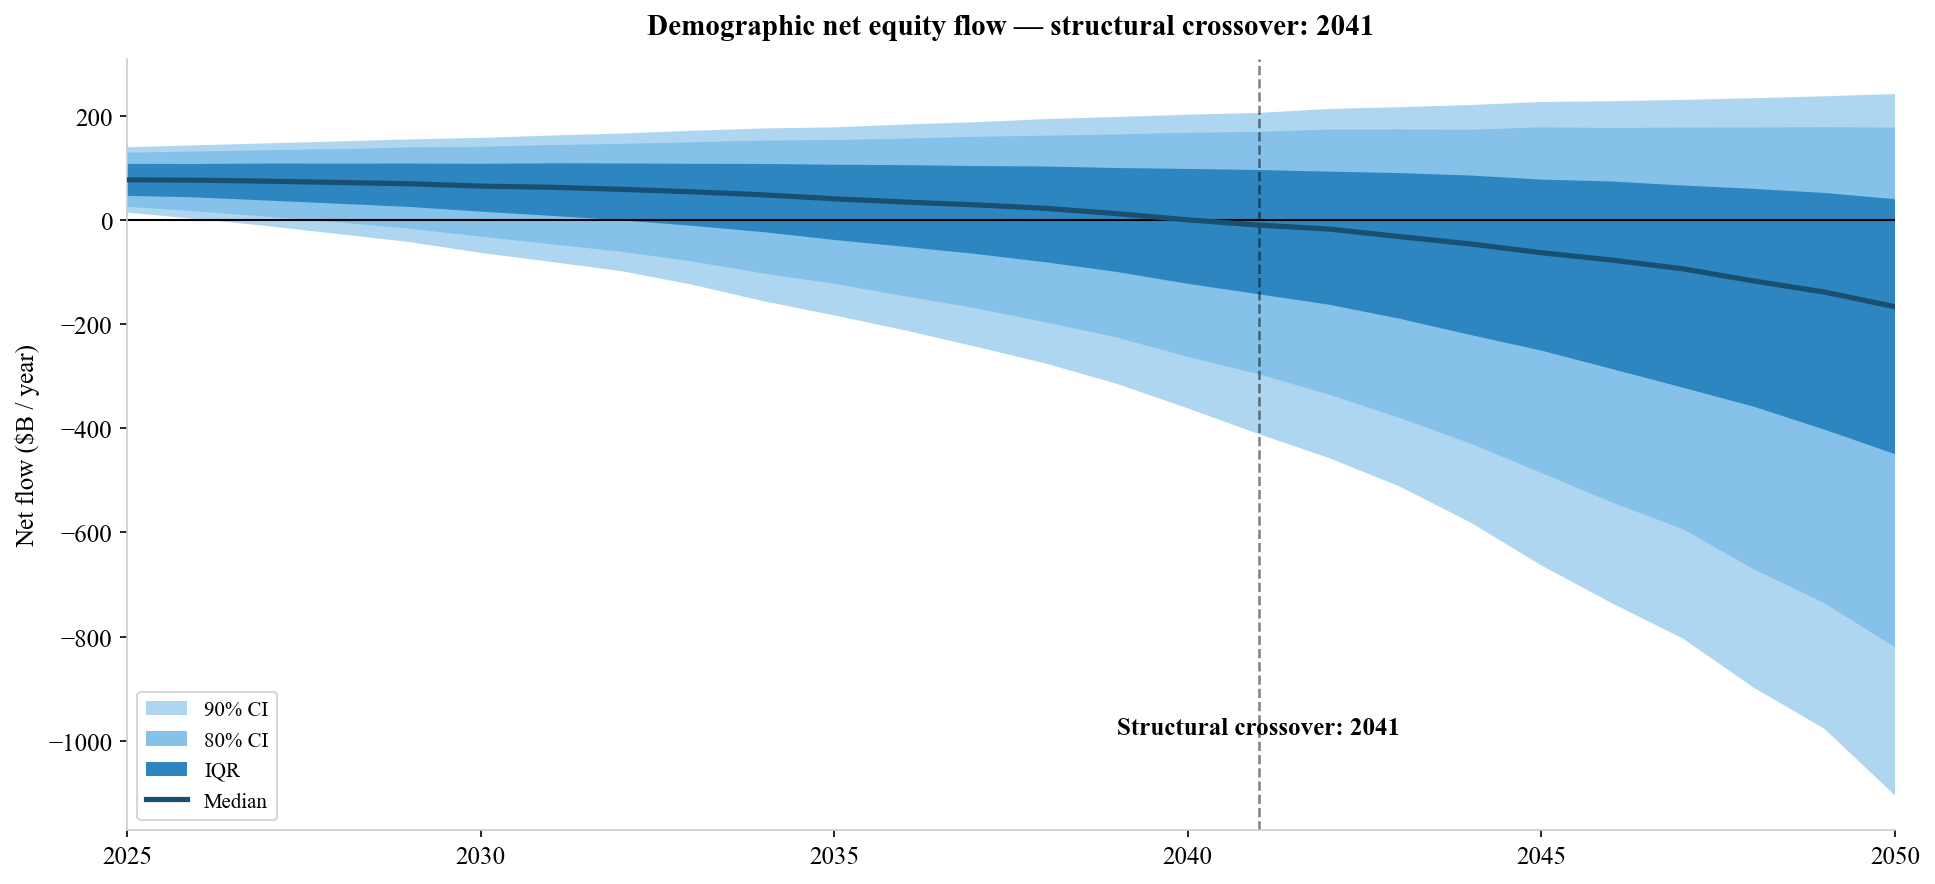


Demographic net flow by year (selected percentiles, $B):
  Year       p5      p25      p50      p75      p95
----------------------------------------------
  2025     14.3     46.5     77.2    107.8    139.8
  2030    -63.1     16.1     65.1    108.0    157.8
  2035   -183.1    -38.2     40.8    106.2    178.0
  2040   -361.6   -122.5      0.4     98.1    202.2
  2045   -663.4   -250.8    -62.8     77.7    226.7
  2050  -1104.9   -449.6   -166.5     40.0    241.9


In [87]:
# ── Fan Chart: When do outflows overtake inflows? ────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

pcts = [5, 10, 25, 50, 75, 90, 95]
demo_percentiles = np.percentile(mc_net_demo, pcts, axis=0)

fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')
ax.set_facecolor('white')

ax.fill_between(YEARS, demo_percentiles[0], demo_percentiles[6],
                color='#AED6F1', label='90% CI', edgecolor='none')
ax.fill_between(YEARS, demo_percentiles[1], demo_percentiles[5],
                color='#85C1E9', label='80% CI', edgecolor='none')
ax.fill_between(YEARS, demo_percentiles[2], demo_percentiles[4],
                color='#2E86C1', label='IQR', edgecolor='none')
ax.plot(YEARS, demo_percentiles[3], '-', color=PAL['navy'], linewidth=2.5, label='Median', zorder=5)

ax.axhline(y=0, color='black', linewidth=1)

med_line = demo_percentiles[3]
cross_idx = np.argmax(med_line < 0)
if cross_idx > 0:
    cross_year = YEARS[cross_idx]
else:
    cross_year = 2050

print(f'Structural crossover (median line crosses zero): {cross_year}')
print(f'Verify: median net flow at {cross_year-1} = ${med_line[cross_idx-1]:.1f}B, at {cross_year} = ${med_line[cross_idx]:.1f}B')

ax.axvline(x=cross_year, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
ax.text(cross_year, ax.get_ylim()[0] * 0.85, f'Structural crossover: {cross_year}',
        fontsize=12, fontweight='bold', color='black', ha='center', va='bottom')

ax.set_title(f'Demographic net equity flow — structural crossover: {cross_year}',
             fontsize=14, fontweight='bold', color='black', pad=12)
ax.set_ylabel('Net flow ($B / year)', fontsize=12, color='black')
ax.set_xlabel('')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim(2025, 2050)
ax.tick_params(colors='black', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(False)

plt.tight_layout()
plt.savefig(f'{OUT}\\mc_demographic_net_flows.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print(f'\nDemographic net flow by year (selected percentiles, $B):')
print(f"{'Year':>6} {'p5':>8} {'p25':>8} {'p50':>8} {'p75':>8} {'p95':>8}")
print(f"{'-'*46}")
for yr_idx, yr in enumerate(YEARS):
    if yr % 5 == 0 or yr == 2025:
        vals = [demo_percentiles[j][yr_idx] for j in [0, 2, 3, 4, 6]]
        print(f'{yr:>6} {vals[0]:>8.1f} {vals[1]:>8.1f} {vals[2]:>8.1f} {vals[3]:>8.1f} {vals[4]:>8.1f}')

## Inflow vs Outflow Decomposition

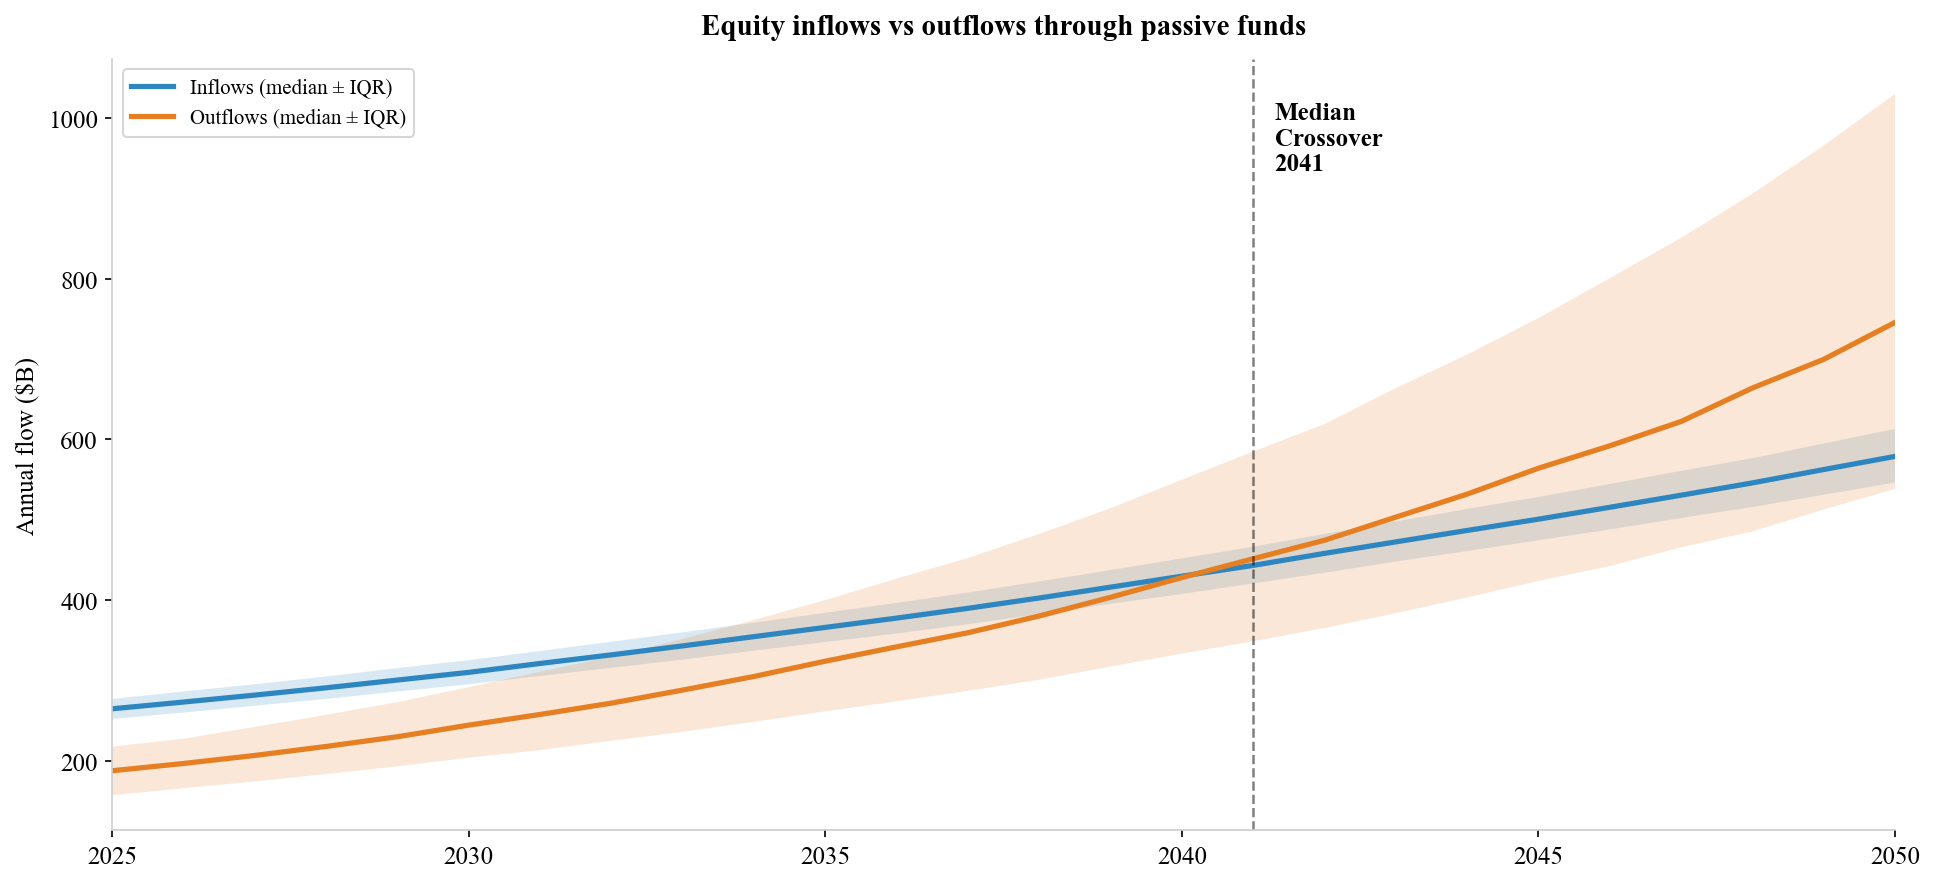

  Year   Inflow_med  Outflow_med    Net_med
------------------------------------------
  2025 $     265.2B $     188.3B $    +77.0B
  2030 $     310.5B $     245.0B $    +65.6B
  2035 $     366.4B $     324.5B $    +42.0B
  2040 $     430.1B $     428.4B $     +1.7B
  2045 $     500.9B $     564.3B $    -63.3B
  2050 $     578.9B $     745.5B $   -166.5B


In [88]:
# ── Inflow vs Outflow decomposition ──────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

in_med  = np.median(mc_inflows, axis=0)
out_med = np.median(mc_outflows, axis=0)
in_iqr  = np.percentile(mc_inflows, [25, 75], axis=0)
out_iqr = np.percentile(mc_outflows, [25, 75], axis=0)

fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')
ax.set_facecolor('white')

# Inflow band + median
ax.fill_between(YEARS, in_iqr[0], in_iqr[1], alpha=0.18, color=PAL['blue'], edgecolor='none')
ax.plot(YEARS, in_med, '-', color=PAL['blue'], linewidth=2.5, label='Inflows (median ± IQR)')

# Outflow band + median
ax.fill_between(YEARS, out_iqr[0], out_iqr[1], alpha=0.18, color=PAL['amber'], edgecolor='none')
ax.plot(YEARS, out_med, '-', color=PAL['amber'], linewidth=2.5, label='Outflows (median ± IQR)')

# Crossover marker
cross_idx = np.argmax(out_med > in_med)
cross_year = YEARS[cross_idx]
ax.axvline(x=cross_year, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
ax.text(cross_year + 0.3, ax.get_ylim()[1] * 0.95, f'Median\nCrossover\n{cross_year}',
        fontsize=12, fontweight='bold', color='black', va='top')

ax.set_title('Equity inflows vs outflows through passive funds',
             fontsize=14, fontweight='bold', color='black', pad=12)
ax.set_ylabel('Annual flow ($B)', fontsize=12, color='black')
ax.set_xlabel('')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(2025, 2050)
ax.tick_params(colors='black', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(False)

plt.tight_layout()
plt.savefig(f'{OUT}\\mc_inflows_vs_outflows.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print(f"{'Year':>6} {'Inflow_med':>12} {'Outflow_med':>12} {'Net_med':>10}")
print(f"{'-'*42}")
for yr_idx, yr in enumerate(YEARS):
    if yr % 5 == 0 or yr == 2025:
        print(f'{yr:>6} ${in_med[yr_idx]:>10.1f}B ${out_med[yr_idx]:>10.1f}B ${in_med[yr_idx]-out_med[yr_idx]:>+9.1f}B')

## Price Impact Fan Chart

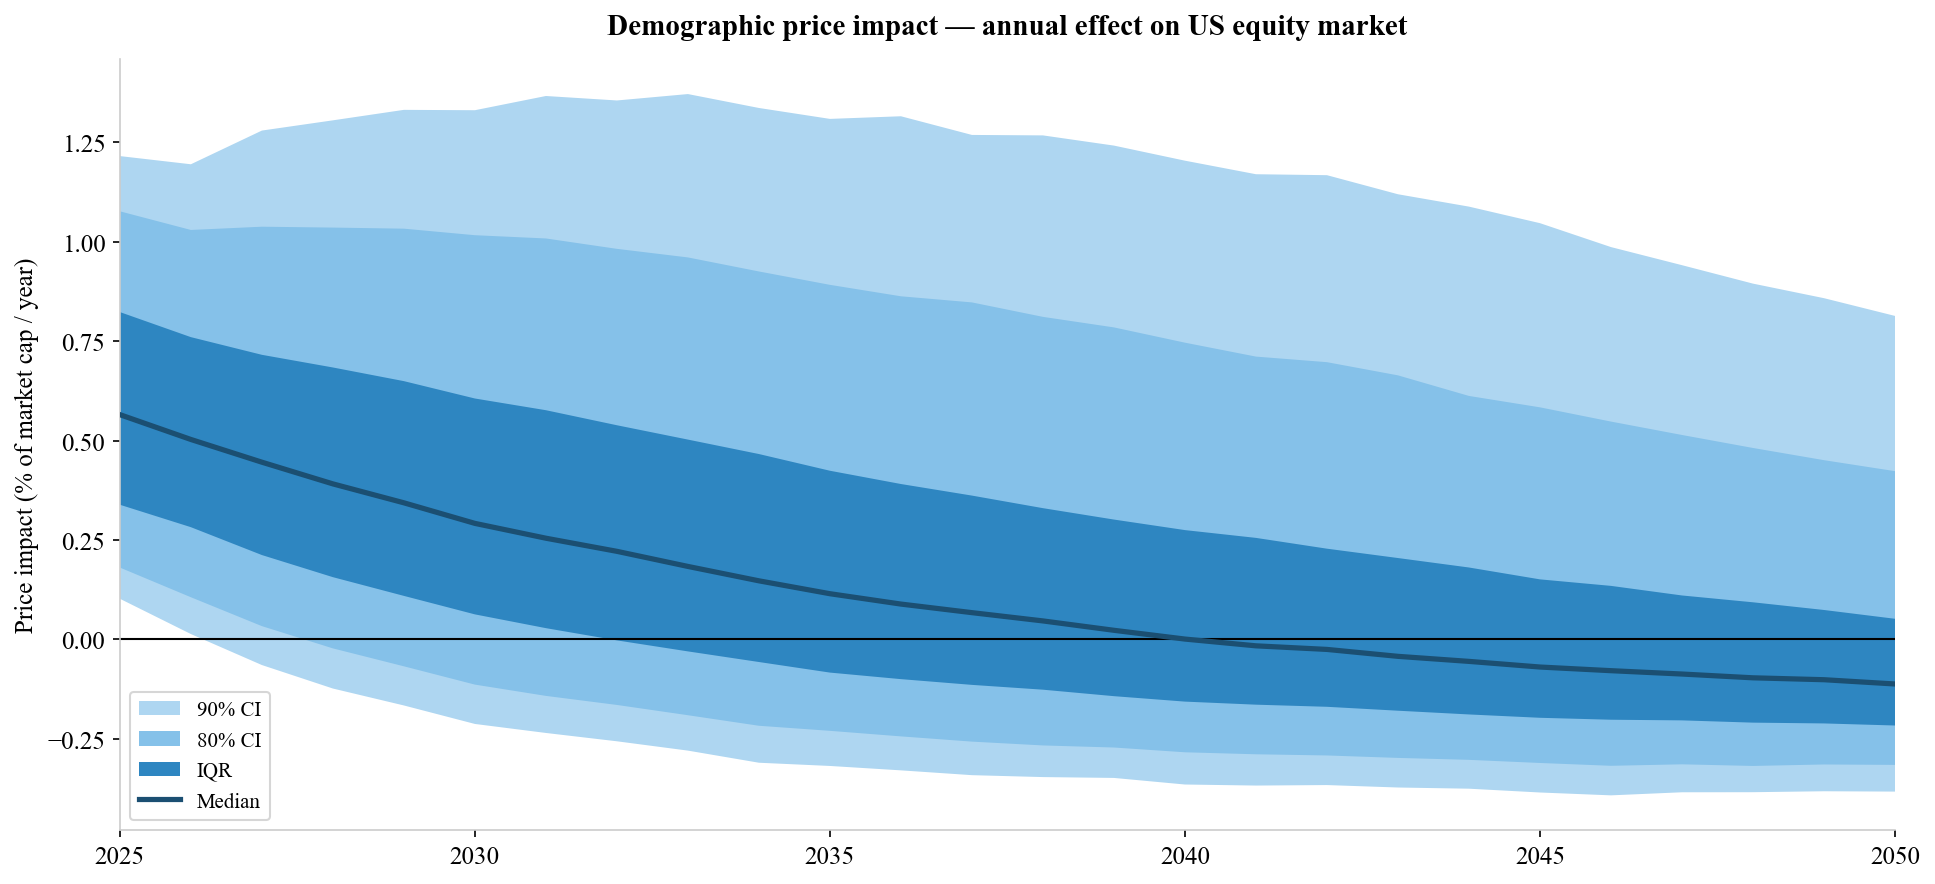

Price impact by year (selected percentiles, % of mkt cap):
  Year       p5      p25      p50      p75      p95
----------------------------------------------
  2025    0.102    0.339    0.565    0.823    1.216
  2030   -0.213    0.063    0.292    0.606    1.331
  2035   -0.318   -0.083    0.115    0.424    1.309
  2040   -0.365   -0.156    0.001    0.275    1.204
  2045   -0.385   -0.197   -0.069    0.151    1.047
  2050   -0.383   -0.217   -0.112    0.052    0.814


In [89]:
# ── Price Impact Fan Chart ───────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

pi_percentiles = np.percentile(mc_price_impact, pcts, axis=0)

fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')
ax.set_facecolor('white')

ax.fill_between(YEARS, pi_percentiles[0], pi_percentiles[6],
                color='#AED6F1', label='90% CI', edgecolor='none')
ax.fill_between(YEARS, pi_percentiles[1], pi_percentiles[5],
                color='#85C1E9', label='80% CI', edgecolor='none')
ax.fill_between(YEARS, pi_percentiles[2], pi_percentiles[4],
                color='#2E86C1', label='IQR', edgecolor='none')
ax.plot(YEARS, pi_percentiles[3], '-', color=PAL['navy'], linewidth=2.5, label='Median', zorder=5)
ax.axhline(y=0, color='black', linewidth=1)

ax.set_title('Demographic price impact — annual effect on US equity market',
             fontsize=14, fontweight='bold', color='black', pad=12)
ax.set_ylabel('Price impact (% of market cap / year)', fontsize=12, color='black')
ax.set_xlabel('')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim(2025, 2050)
ax.tick_params(colors='black', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(False)

plt.tight_layout()
plt.savefig(f'{OUT}\\mc_price_impact.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print(f'Price impact by year (selected percentiles, % of mkt cap):')
print(f"{'Year':>6} {'p5':>8} {'p25':>8} {'p50':>8} {'p75':>8} {'p95':>8}")
print(f"{'-'*46}")
for yr_idx, yr in enumerate(YEARS):
    if yr % 5 == 0 or yr == 2025:
        vals = [pi_percentiles[j][yr_idx] for j in [0, 2, 3, 4, 6]]
        print(f'{yr:>6} {vals[0]:>8.3f} {vals[1]:>8.3f} {vals[2]:>8.3f} {vals[3]:>8.3f} {vals[4]:>8.3f}')

## Cumulative Price Drag

In [90]:
# ── Cumulative Price Drag ($ trillion and % of market cap) ────────────
# Computes the total cumulative market-cap reduction from demographic
# net flows over the projection horizon, using the MC price impact paths.
# Paper reference: Section 6.1.

# Annual dollar drag per path = price_impact_pct / 100 × mktcap (in $B)
annual_drag_B = mc_price_impact / 100 * mc_mktcap
cumulative_drag_B = np.cumsum(annual_drag_B, axis=1)

# Cumulative % of market cap: sum of annual price_impact_pct
cumulative_pct = np.cumsum(mc_price_impact, axis=1)

# Report at key years
print(f"{'='*70}")
print('CUMULATIVE DEMOGRAPHIC PRICE DRAG')
print(f"{'='*70}")
print(f"{'Year':>6}  {'Median $':>12}  {'IQR $':>24}  {'Median %':>10}  {'IQR %':>20}")
print(f"{'-'*74}")
for yr_idx, yr in enumerate(YEARS):
    if yr in [2025, 2030, 2035, 2040, 2045, 2050]:
        med_B = np.median(cumulative_drag_B[:, yr_idx])
        q25_B = np.percentile(cumulative_drag_B[:, yr_idx], 25)
        q75_B = np.percentile(cumulative_drag_B[:, yr_idx], 75)
        med_pct = np.median(cumulative_pct[:, yr_idx])
        q25_pct = np.percentile(cumulative_pct[:, yr_idx], 25)
        q75_pct = np.percentile(cumulative_pct[:, yr_idx], 75)
        print(f'{yr:>6}  ${med_B/1000:>10.1f}T  [{q25_B/1000:>8.1f}T, {q75_B/1000:>8.1f}T]'
              f'  {med_pct:>+8.1f}%  [{q25_pct:>+6.1f}%, {q75_pct:>+6.1f}%]')

# Summary for paper Section 6.1
med_2050_T = np.median(cumulative_drag_B[:, 25]) / 1000
q25_2050_T = np.percentile(cumulative_drag_B[:, 25], 25) / 1000
q75_2050_T = np.percentile(cumulative_drag_B[:, 25], 75) / 1000
med_2050_pct = np.median(cumulative_pct[:, 25])
q25_2050_pct = np.percentile(cumulative_pct[:, 25], 25)
q75_2050_pct = np.percentile(cumulative_pct[:, 25], 75)
print(f'\nPaper Section 6.1 summary:')
print(f'  Cumulative 2025-2050 median: ${med_2050_T:.1f}T ({med_2050_pct:+.1f}%)')
print(f'  IQR: ${q25_2050_T:.1f}T to ${q75_2050_T:.1f}T ({q25_2050_pct:+.1f}% to {q75_2050_pct:+.1f}%)')


CUMULATIVE DEMOGRAPHIC PRICE DRAG
  Year      Median $                     IQR $    Median %                 IQR %
--------------------------------------------------------------------------
  2025  $       0.4T  [     0.2T,      0.5T]      +0.6%  [  +0.3%,   +0.8%]
  2030  $       2.0T  [     1.4T,      2.8T]      +2.6%  [  +1.7%,   +3.8%]
  2035  $       3.2T  [     1.5T,      4.9T]      +3.6%  [  +2.0%,   +6.0%]
  2040  $       3.5T  [    -0.2T,      6.9T]      +3.9%  [  +1.6%,   +7.5%]
  2045  $       2.3T  [    -5.1T,      8.4T]      +3.8%  [  +1.0%,   +8.4%]
  2050  $      -1.3T  [   -15.1T,      9.1T]      +3.3%  [  +0.2%,   +8.8%]

Paper Section 6.1 summary:
  Cumulative 2025-2050 median: $-1.3T (+3.3%)
  IQR: $-15.1T to $9.1T (+0.2% to +8.8%)


## 3x3 Scenario Table

In [91]:
M_labels = ['M=3', 'M=5', 'M=7']
P_labels = ['1.0 pp/yr', '1.4 pp/yr', '1.8 pp/yr']

print(f"{'Scenario':<30} {'Crossover':>10} {'Net 2035':>10} {'Net 2050':>10} {'Impact 2050':>12}")
print(f"{'-'*75}")
idx = 0
for m_label in M_labels:
    for p_label in P_labels:
        sc = data['scenario_crossovers'][idx]
        n35 = data['scenario_net_2035'][idx]
        n50 = data['scenario_net_2050'][idx]
        i50 = data['scenario_impact_2050'][idx]
        print(f"{m_label+' x '+p_label:<30} {int(sc):>10} ${n35:>8.1f}B ${n50:>8.1f}B {i50:>+10.3f}%")
        idx += 1


Scenario                        Crossover   Net 2035   Net 2050  Impact 2050
---------------------------------------------------------------------------
M=3 x 1.0 pp/yr                      2043 $    51.0B $  -100.2B     -0.050%
M=3 x 1.4 pp/yr                      2043 $    51.0B $  -100.2B     -0.052%
M=3 x 1.8 pp/yr                      2043 $    51.0B $  -100.2B     -0.052%
M=5 x 1.0 pp/yr                      2043 $    51.0B $   -99.9B     -0.083%
M=5 x 1.4 pp/yr                      2043 $    51.0B $   -99.9B     -0.087%
M=5 x 1.8 pp/yr                      2043 $    51.0B $   -99.8B     -0.087%
M=7 x 1.0 pp/yr                      2043 $    51.0B $   -99.6B     -0.115%
M=7 x 1.4 pp/yr                      2043 $    51.0B $   -99.5B     -0.122%
M=7 x 1.8 pp/yr                      2043 $    51.0B $   -99.5B     -0.122%


## Outflow Decomposition by Age Group (Appendix)

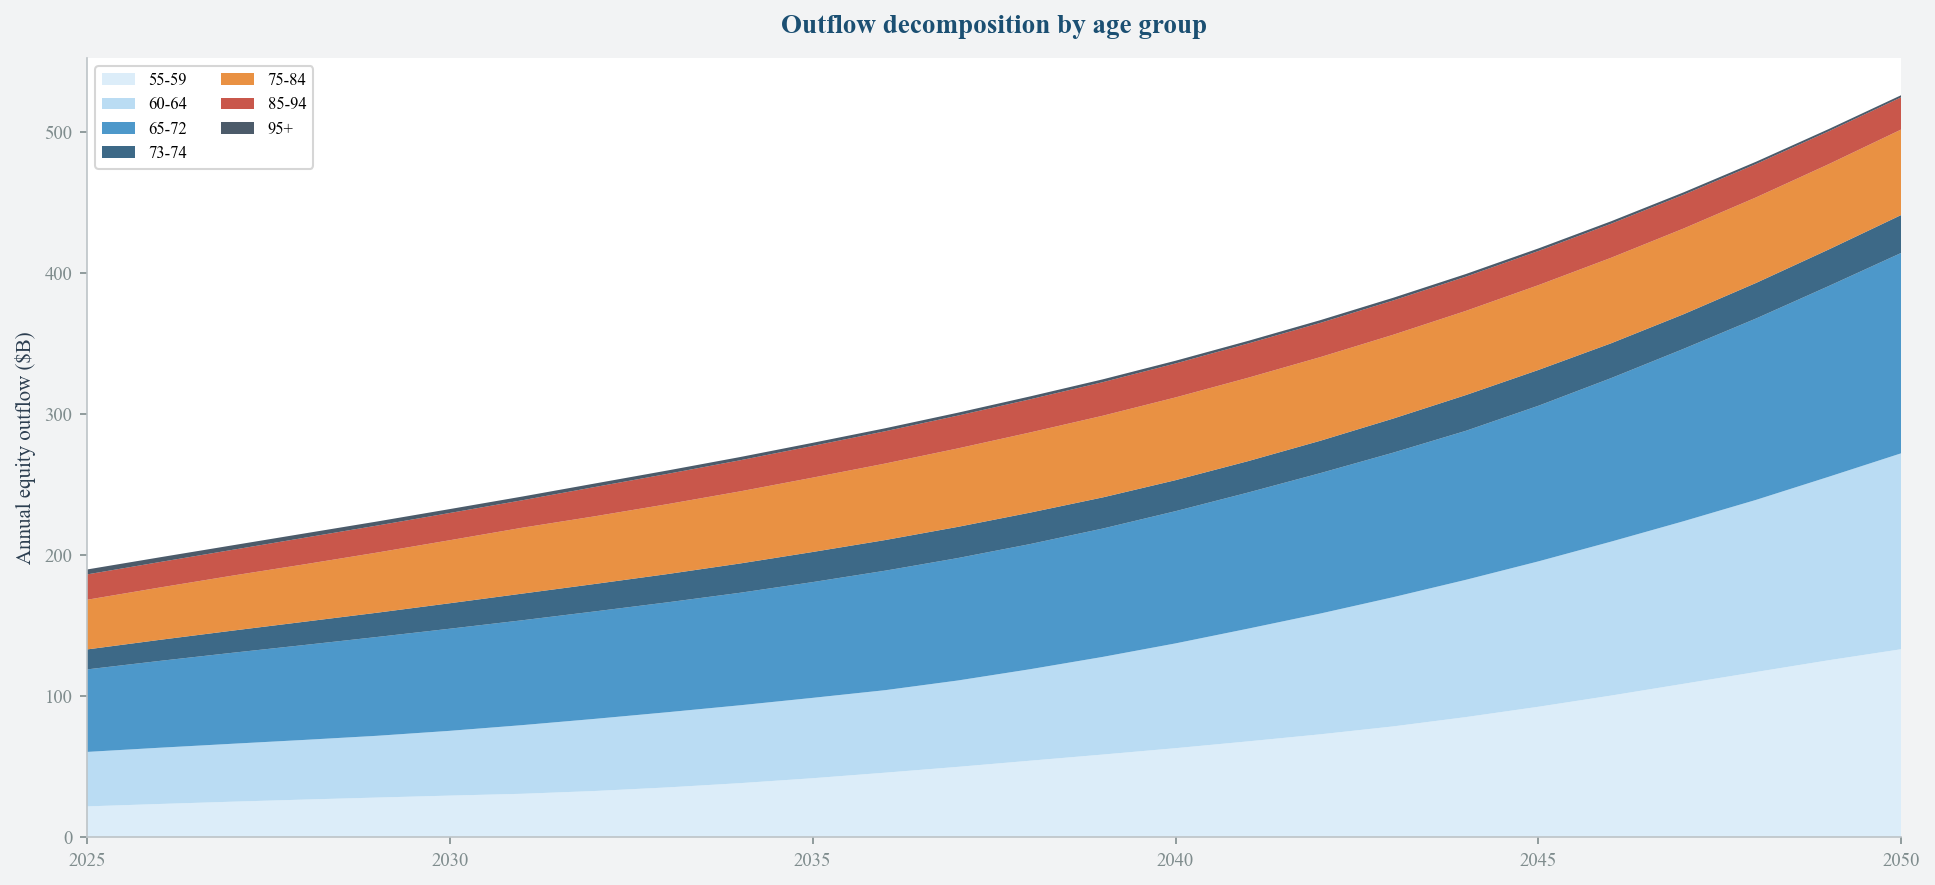


2050 outflow shares:
  55-59: 25.4%
  60-64: 26.4%
  65-72: 27.0%
  73-74: 5.1%
  75-84: 11.5%
  85-94: 4.3%
  95+: 0.3%

Balance trajectory ($K, deterministic 9.9%):
     Group        2025        2035        2050
     55-59  $     538K  $   1,049K  $   2,858K
     60-64  $     538K  $     884K  $   1,867K
     65-72  $     609K  $     861K  $   1,446K
     73-74  $     609K  $     769K  $   1,091K
     75-84  $     462K  $     507K  $     583K
     85-94  $     462K  $     358K  $     244K
       95+  $     462K  $     214K  $      67K


In [92]:
age_labels = ['55-59', '60-64', '65-72', '73-74', '75-84', '85-94', '95+']
group_colors = [PAL['ice'], PAL['sky'], PAL['blue'], PAL['navy'],
                PAL['amber'], PAL['brick'], PAL['charcoal']]

fig, ax = plt.subplots(figsize=(13, 6))
ax.stackplot(YEARS, outflow_by_group, labels=age_labels,
             colors=group_colors, alpha=0.85)
ax.set_title('Outflow decomposition by age group',
             fontsize=13, fontweight='bold', color=PAL['navy'], pad=12)
ax.set_ylabel('Annual equity outflow ($B)')
ax.set_xlim(2025, 2050)
ax.legend(loc='upper left', fontsize=8, ncol=2)
clean_spines(ax)
plt.tight_layout()
plt.savefig(f'{OUT}\\outflow_decomposition_by_age.png', dpi=300, bbox_inches='tight')
plt.show()

total_2050 = outflow_by_group[:, 25].sum()
print(f'\n2050 outflow shares:')
for j, ag in enumerate(age_labels):
    print(f'  {ag}: {outflow_by_group[j, 25]/total_2050*100:.1f}%')

print(f'\nBalance trajectory ($K, deterministic 9.9%):')
print(f"{'Group':>10}  {'2025':>10}  {'2035':>10}  {'2050':>10}")
for j, ag in enumerate(age_labels):
    print(f'{ag:>10}  ${balance_snapshots[0,j]:>8,.0f}K  ${balance_snapshots[1,j]:>8,.0f}K  ${balance_snapshots[2,j]:>8,.0f}K')


## Crossover Analysis

CROSSOVER ANALYSIS — Demographic Net Flow
  Simulations where outflows overtake inflows: 22804/25000 (91.2%)
  Earliest crossover:  2025
  10th percentile:     2027
  25th percentile:     2029
  Median crossover:    2031
  75th percentile:     2036
  90th percentile:     2042
  Latest crossover:    2050

CROSSOVER ANALYSIS — Total Net Flow (with buyback offset)
  Simulations where total flow goes negative: 1115/25000 (4.5%)
  Median crossover:    2041


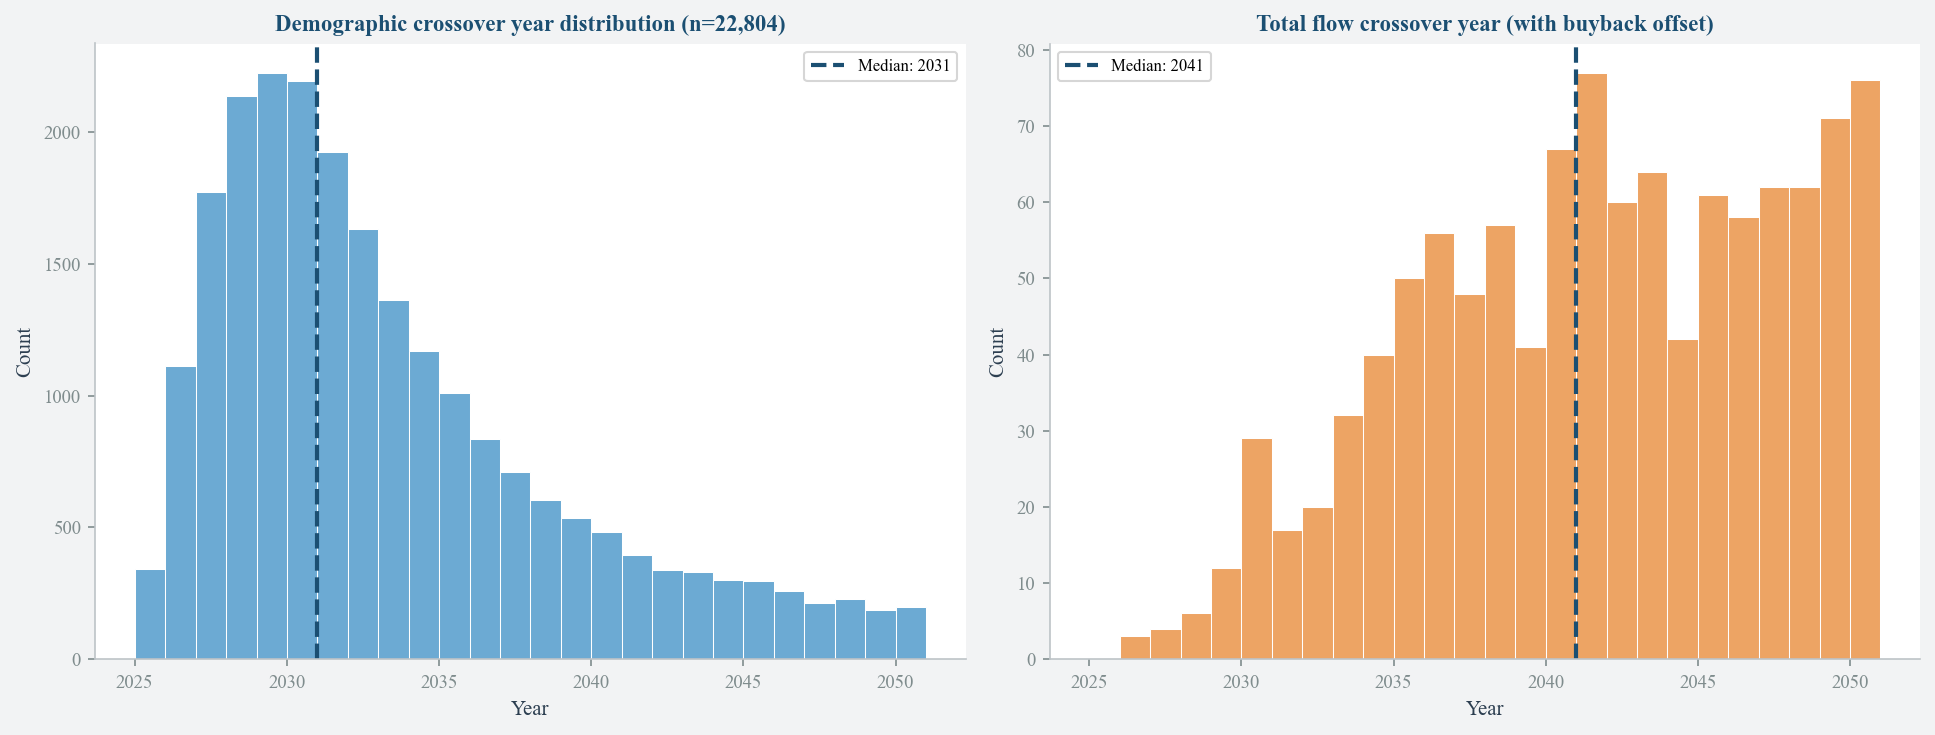

In [93]:
# ── Crossover analysis ──────────────────────────────────────────────────────
valid_demo = mc_crossover_demo[mc_crossover_demo < 2099]
valid_total = mc_crossover_total[mc_crossover_total < 2099]

print(f"{'='*60}")
print(f'CROSSOVER ANALYSIS — Demographic Net Flow')
print(f"{'='*60}")
print(f'  Simulations where outflows overtake inflows: {len(valid_demo)}/{N_SIMS} ({len(valid_demo)/N_SIMS*100:.1f}%)')
if len(valid_demo) > 0:
    print(f'  Earliest crossover:  {int(valid_demo.min())}')
    print(f'  10th percentile:     {int(np.percentile(valid_demo, 10))}')
    print(f'  25th percentile:     {int(np.percentile(valid_demo, 25))}')
    print(f'  Median crossover:    {int(np.median(valid_demo))}')
    print(f'  75th percentile:     {int(np.percentile(valid_demo, 75))}')
    print(f'  90th percentile:     {int(np.percentile(valid_demo, 90))}')
    print(f'  Latest crossover:    {int(valid_demo.max())}')

print(f"\n{'='*60}")
print(f'CROSSOVER ANALYSIS — Total Net Flow (with buyback offset)')
print(f"{'='*60}")
print(f'  Simulations where total flow goes negative: {len(valid_total)}/{N_SIMS} ({len(valid_total)/N_SIMS*100:.1f}%)')
if len(valid_total) > 0:
    print(f'  Median crossover:    {int(np.median(valid_total))}')
else:
    print(f'  → Buybacks prevent total flow from going negative in most simulations.')

# ── Histograms (RESTYLED) ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if len(valid_demo) > 5:
    sns.histplot(valid_demo, bins=range(2025, 2052), color=PAL['blue'], alpha=0.7,
                 edgecolor='white', linewidth=0.5, ax=axes[0])
    axes[0].axvline(x=np.median(valid_demo), color=PAL['navy'], linewidth=2,
                    linestyle='--', label=f'Median: {int(np.median(valid_demo))}')
    axes[0].set_title(f'Demographic crossover year distribution (n={len(valid_demo):,})',
                      fontsize=11, fontweight='bold', color=PAL['navy'])
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Count')
    axes[0].legend(fontsize=8)
    clean_spines(axes[0])

if len(valid_total) > 5:
    sns.histplot(valid_total, bins=range(2025, 2052), color=PAL['amber'], alpha=0.7,
                 edgecolor='white', linewidth=0.5, ax=axes[1])
    axes[1].axvline(x=np.median(valid_total), color=PAL['navy'], linewidth=2,
                    linestyle='--', label=f'Median: {int(np.median(valid_total))}')
    axes[1].set_title('Total flow crossover year (with buyback offset)',
                      fontsize=11, fontweight='bold', color=PAL['navy'])
    axes[1].set_xlabel('Year')
    axes[1].legend(fontsize=8)
    clean_spines(axes[1])
else:
    axes[1].text(0.5, 0.5, f'Only {len(valid_total)} crossovers',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUT}\\mc_crossover_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

CROSSOVER ANALYSIS — Demographic Net Flow
  Simulations where outflows overtake inflows: 22804/25000 (91.2%)
  Earliest crossover:  2025
  10th percentile:     2027
  25th percentile:     2029
  Median crossover:    2031
  75th percentile:     2036
  90th percentile:     2042
  Latest crossover:    2050

CROSSOVER ANALYSIS — Total Net Flow (with buyback offset)
  Simulations where total flow goes negative: 1115/25000 (4.5%)
  Median crossover:    2041


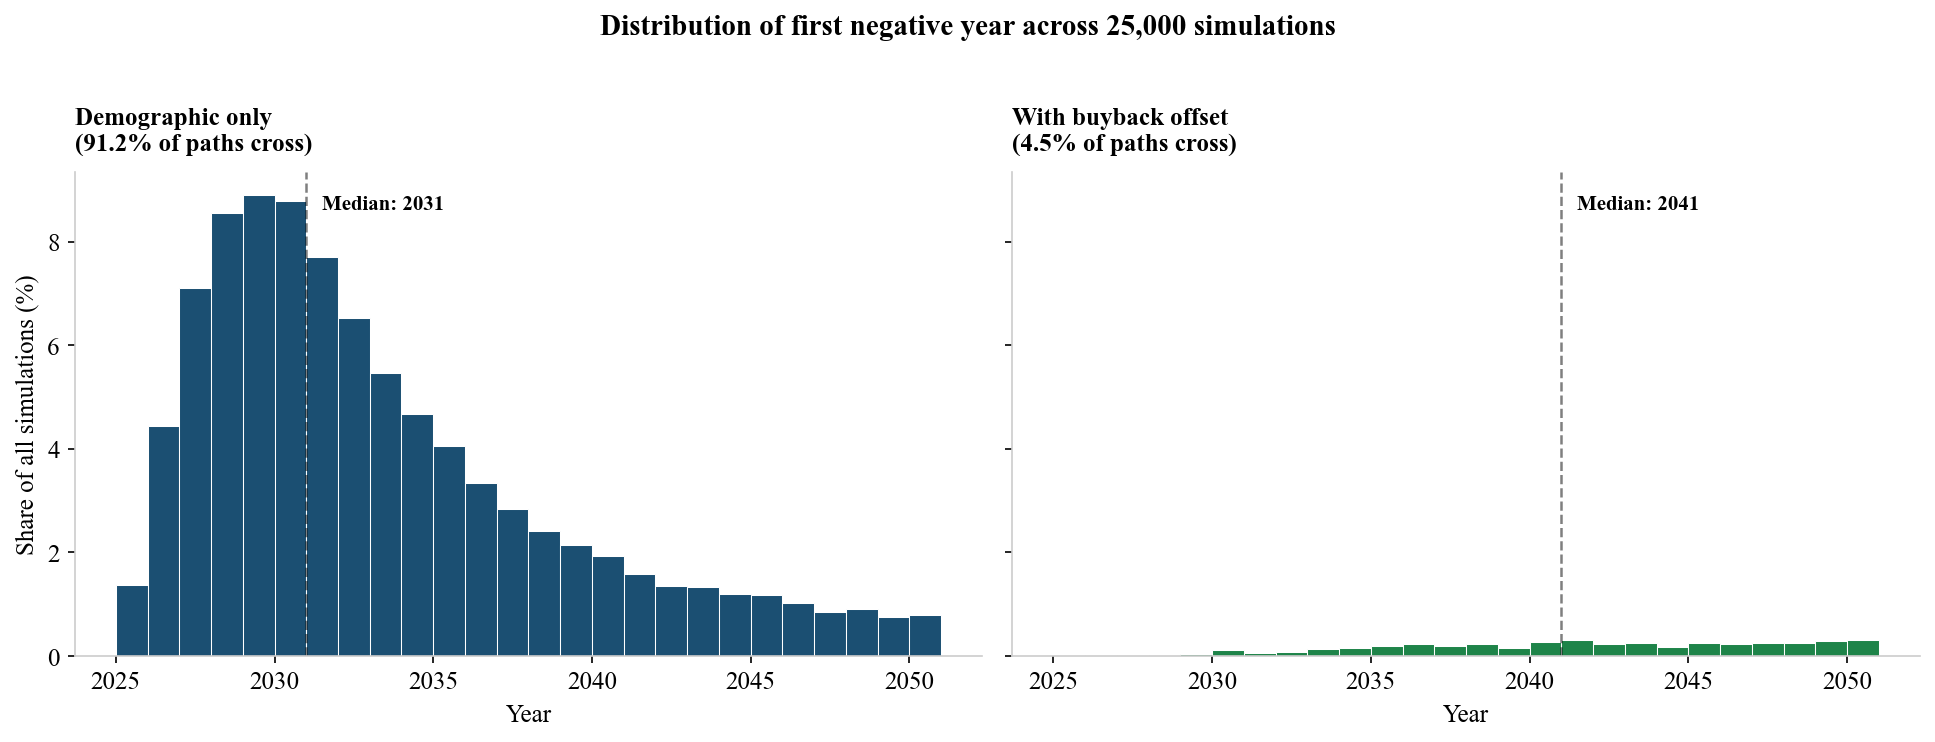

In [94]:
# ── Crossover analysis ──────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

valid_demo = mc_crossover_demo[mc_crossover_demo < 2099]
valid_total = mc_crossover_total[mc_crossover_total < 2099]

print(f"{'='*60}")
print(f'CROSSOVER ANALYSIS — Demographic Net Flow')
print(f"{'='*60}")
print(f'  Simulations where outflows overtake inflows: {len(valid_demo)}/{N_SIMS} ({len(valid_demo)/N_SIMS*100:.1f}%)')
if len(valid_demo) > 0:
    print(f'  Earliest crossover:  {int(valid_demo.min())}')
    print(f'  10th percentile:     {int(np.percentile(valid_demo, 10))}')
    print(f'  25th percentile:     {int(np.percentile(valid_demo, 25))}')
    print(f'  Median crossover:    {int(np.median(valid_demo))}')
    print(f'  75th percentile:     {int(np.percentile(valid_demo, 75))}')
    print(f'  90th percentile:     {int(np.percentile(valid_demo, 90))}')
    print(f'  Latest crossover:    {int(valid_demo.max())}')

print(f"\n{'='*60}")
print(f'CROSSOVER ANALYSIS — Total Net Flow (with buyback offset)')
print(f"{'='*60}")
print(f'  Simulations where total flow goes negative: {len(valid_total)}/{N_SIMS} ({len(valid_total)/N_SIMS*100:.1f}%)')
if len(valid_total) > 0:
    print(f'  Median crossover:    {int(np.median(valid_total))}')
else:
    print(f'  → Buybacks prevent total flow from going negative in most simulations.')

# ── Histograms — both normalized to % of ALL 25,000 simulations ──────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white', sharey=True)

bins = range(2025, 2052)

med_demo = int(np.median(valid_demo)) if len(valid_demo) > 5 else None
med_total = int(np.median(valid_total)) if len(valid_total) > 5 else None

if len(valid_demo) > 5:
    weights_demo = np.ones_like(valid_demo) / N_SIMS * 100
    axes[0].hist(valid_demo, bins=bins, weights=weights_demo,
                 color=PAL['navy'], alpha=1.0, edgecolor='white', linewidth=0.5)
    axes[0].axvline(x=med_demo, color='black', linewidth=1.2,
                    linestyle='--', alpha=0.5)
    axes[0].set_title(f'Demographic only\n({len(valid_demo)/N_SIMS*100:.1f}% of paths cross)',
                      fontsize=12, fontweight='bold', color='black', pad=10, loc='left')
    axes[0].set_xlabel('Year', fontsize=12, color='black')
    axes[0].set_ylabel('Share of all simulations (%)', fontsize=12, color='black')

if len(valid_total) > 5:
    weights_total = np.ones_like(valid_total) / N_SIMS * 100
    axes[1].hist(valid_total, bins=bins, weights=weights_total,
                 color='#1E8449', alpha=1.0, edgecolor='white', linewidth=0.5)
    axes[1].axvline(x=med_total, color='black', linewidth=1.2,
                    linestyle='--', alpha=0.5)
    axes[1].set_title(f'With buyback offset\n({len(valid_total)/N_SIMS*100:.1f}% of paths cross)',
                      fontsize=12, fontweight='bold', color='black', pad=10, loc='left')
    axes[1].set_xlabel('Year', fontsize=12, color='black')
else:
    axes[1].text(0.5, 0.5, f'Only {len(valid_total)} crossovers',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)

for ax in axes:
    ax.set_facecolor('white')
    ax.tick_params(colors='black', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.grid(False)

fig.suptitle('Distribution of first negative year across 25,000 simulations',
             fontsize=14, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Median labels after layout
if med_demo is not None:
    yd = axes[0].get_ylim()[1]
    axes[0].text(med_demo + 0.5, yd * 0.95, f'Median: {med_demo}',
                 fontsize=10, fontweight='bold', color='black',
                 va='top', ha='left', clip_on=False)

if med_total is not None:
    yt = axes[1].get_ylim()[1]
    axes[1].text(med_total + 0.5, yt * 0.95, f'Median: {med_total}',
                 fontsize=10, fontweight='bold', color='black',
                 va='top', ha='left', clip_on=False)

plt.savefig(f'{OUT}\\mc_crossover_histograms.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## Crossover Probability Curve

Permanent crossover (demo): 17454/25000 paths (69.8%)
Permanent crossover (total): 79/25000 paths (0.3%)


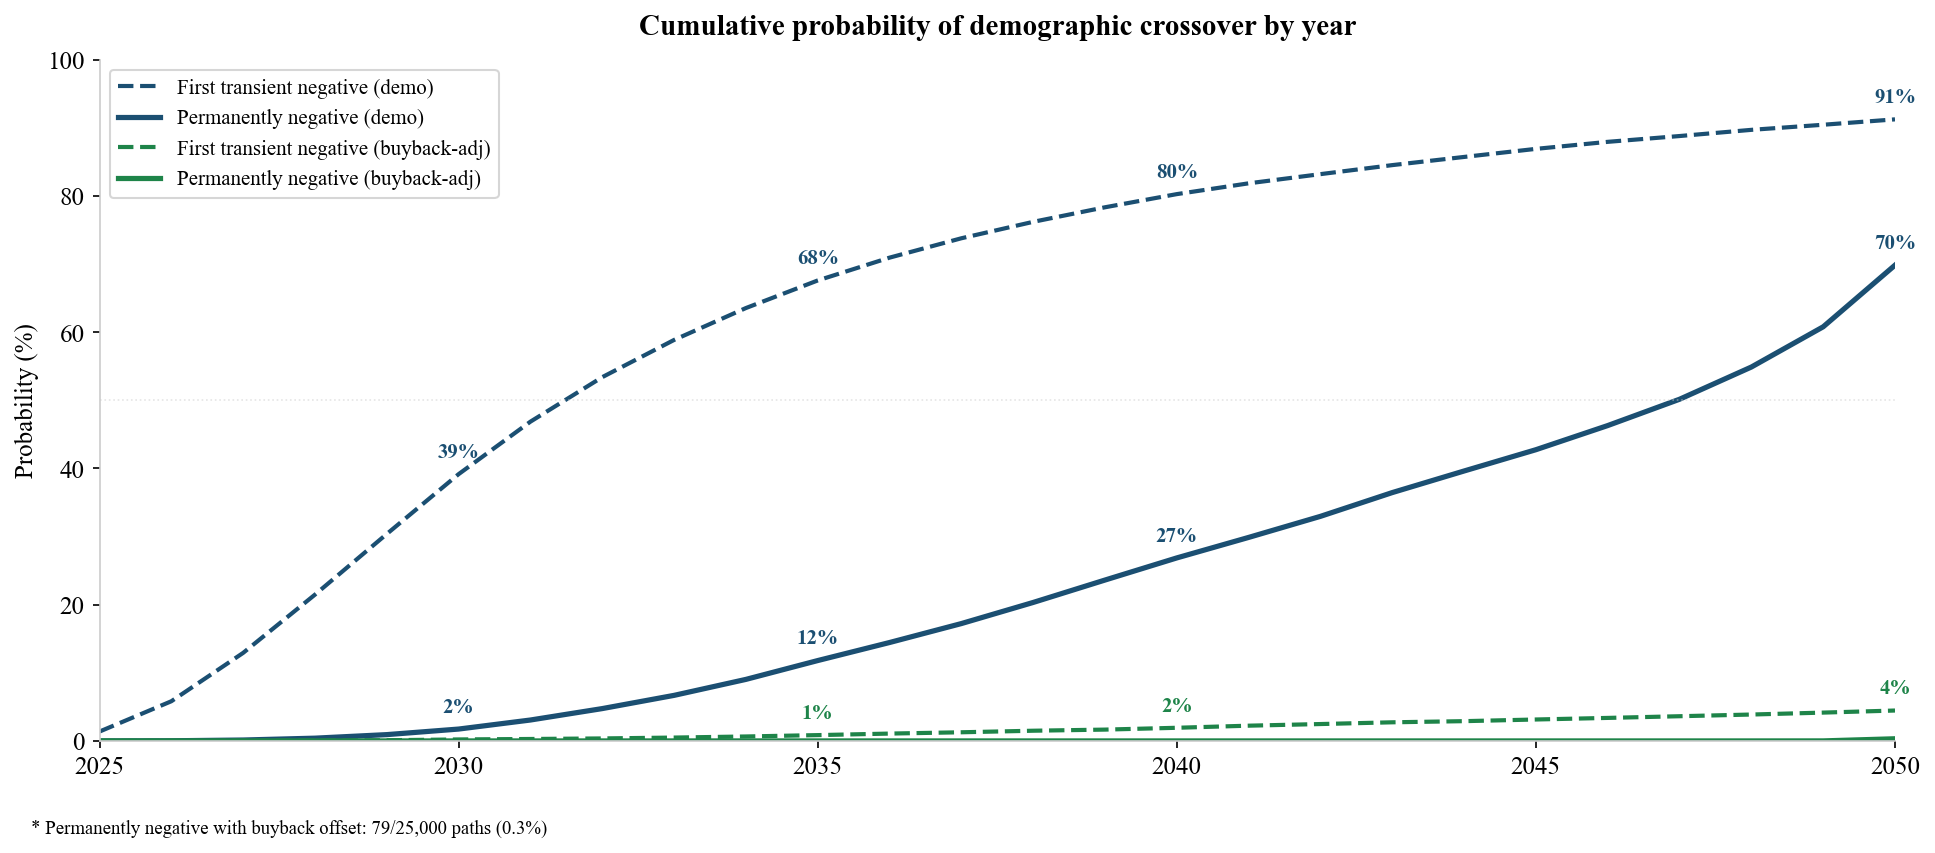


Crossover probability by year:
  Year    Demo 1st   Demo perm   Total 1st  Total perm
--------------------------------------------------
  2025        1.4%        0.0%        0.0%        0.0%
  2030       39.1%        1.7%        0.2%        0.0%
  2035       67.6%       11.8%        0.9%        0.0%
  2040       80.2%       26.9%        1.9%        0.0%
  2045       86.9%       42.7%        3.1%        0.0%
  2050       91.2%       69.8%        4.5%        0.3%


In [95]:
# ── Crossover Probability Curve ──────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')
ax.set_facecolor('white')

C_GREEN = '#1E8449'

# ── First transient negative ──
prob_demo  = [(mc_crossover_demo <= yr).mean() * 100 for yr in YEARS]
prob_total = [(mc_crossover_total <= yr).mean() * 100 for yr in YEARS]

# ── Permanently negative: stays negative for ALL remaining years ──
def permanent_crossover(net_flows, years):
    n_sims, n_years = net_flows.shape
    perm_cross = np.full(n_sims, 2099.0)
    for i in range(n_sims):
        for t in range(n_years):
            if np.all(net_flows[i, t:] < 0):
                perm_cross[i] = years[t]
                break
    return perm_cross

perm_demo = permanent_crossover(mc_net_demo, YEARS)
perm_total = permanent_crossover(mc_net_total, YEARS)

prob_perm_demo  = [(perm_demo <= yr).mean() * 100 for yr in YEARS]
prob_perm_total = [(perm_total <= yr).mean() * 100 for yr in YEARS]

n_perm_total = (perm_total < 2099).sum()
pct_perm_total = (perm_total < 2099).mean() * 100

print(f'Permanent crossover (demo): {(perm_demo < 2099).sum()}/{N_SIMS} paths ({(perm_demo < 2099).mean()*100:.1f}%)')
print(f'Permanent crossover (total): {n_perm_total}/{N_SIMS} paths ({pct_perm_total:.1f}%)')

# ── Plot — 4 lines ──
ax.plot(YEARS, prob_demo, '--', color=PAL['navy'], linewidth=2,
        label='First transient negative (demo)')
ax.plot(YEARS, prob_perm_demo, '-', color=PAL['navy'], linewidth=2.5,
        label='Permanently negative (demo)')
ax.plot(YEARS, prob_total, '--', color=C_GREEN, linewidth=2,
        label='First transient negative (buyback-adj)')
ax.plot(YEARS, prob_perm_total, '-', color=C_GREEN, linewidth=2.5,
        label='Permanently negative (buyback-adj)')

ax.axhline(y=50, color='#CCCCCC', linewidth=0.8, linestyle=':', alpha=0.5)

# Annotate key years — only demo and buyback transient, NOT perm buyback
for series_data, color in [(prob_demo, PAL['navy']),
                            (prob_perm_demo, PAL['navy']),
                            (prob_total, C_GREEN)]:
    for yr in [2030, 2035, 2040, 2050]:
        idx = yr - 2025
        val = series_data[idx]
        if val > 0.5:
            ax.annotate(f'{val:.0f}%', xy=(yr, val),
                       fontsize=10, fontweight='bold', color=color,
                       textcoords='offset points', xytext=(0, 8), ha='center')

ax.set_title('Cumulative probability of demographic crossover by year',
             fontsize=14, fontweight='bold', color='black', pad=12)
ax.set_ylabel('Probability (%)', fontsize=12, color='black')
ax.set_xlim(2025, 2050)
ax.set_ylim(0, 100)
ax.legend(loc='upper left', fontsize=10)
ax.tick_params(colors='black', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(False)

# Footnote below chart area
fig.text(0.02, 0.01,
         f'* Permanently negative with buyback offset: {n_perm_total:,}/{N_SIMS:,} paths ({pct_perm_total:.1f}%)',
         fontsize=9, color='black', va='bottom', ha='left')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(f'{OUT}\\mc_crossover_probability.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

# Hard numbers
print('\nCrossover probability by year:')
print(f"{'Year':>6}  {'Demo 1st':>10}  {'Demo perm':>10}  {'Total 1st':>10}  {'Total perm':>10}")
print(f"{'-'*50}")
for yr_idx, yr in enumerate(YEARS):
    if yr % 5 == 0 or yr == 2025:
        print(f'{yr:>6}  {prob_demo[yr_idx]:>9.1f}%  {prob_perm_demo[yr_idx]:>9.1f}%  {prob_total[yr_idx]:>9.1f}%  {prob_perm_total[yr_idx]:>9.1f}%')

## Crash Stress Test

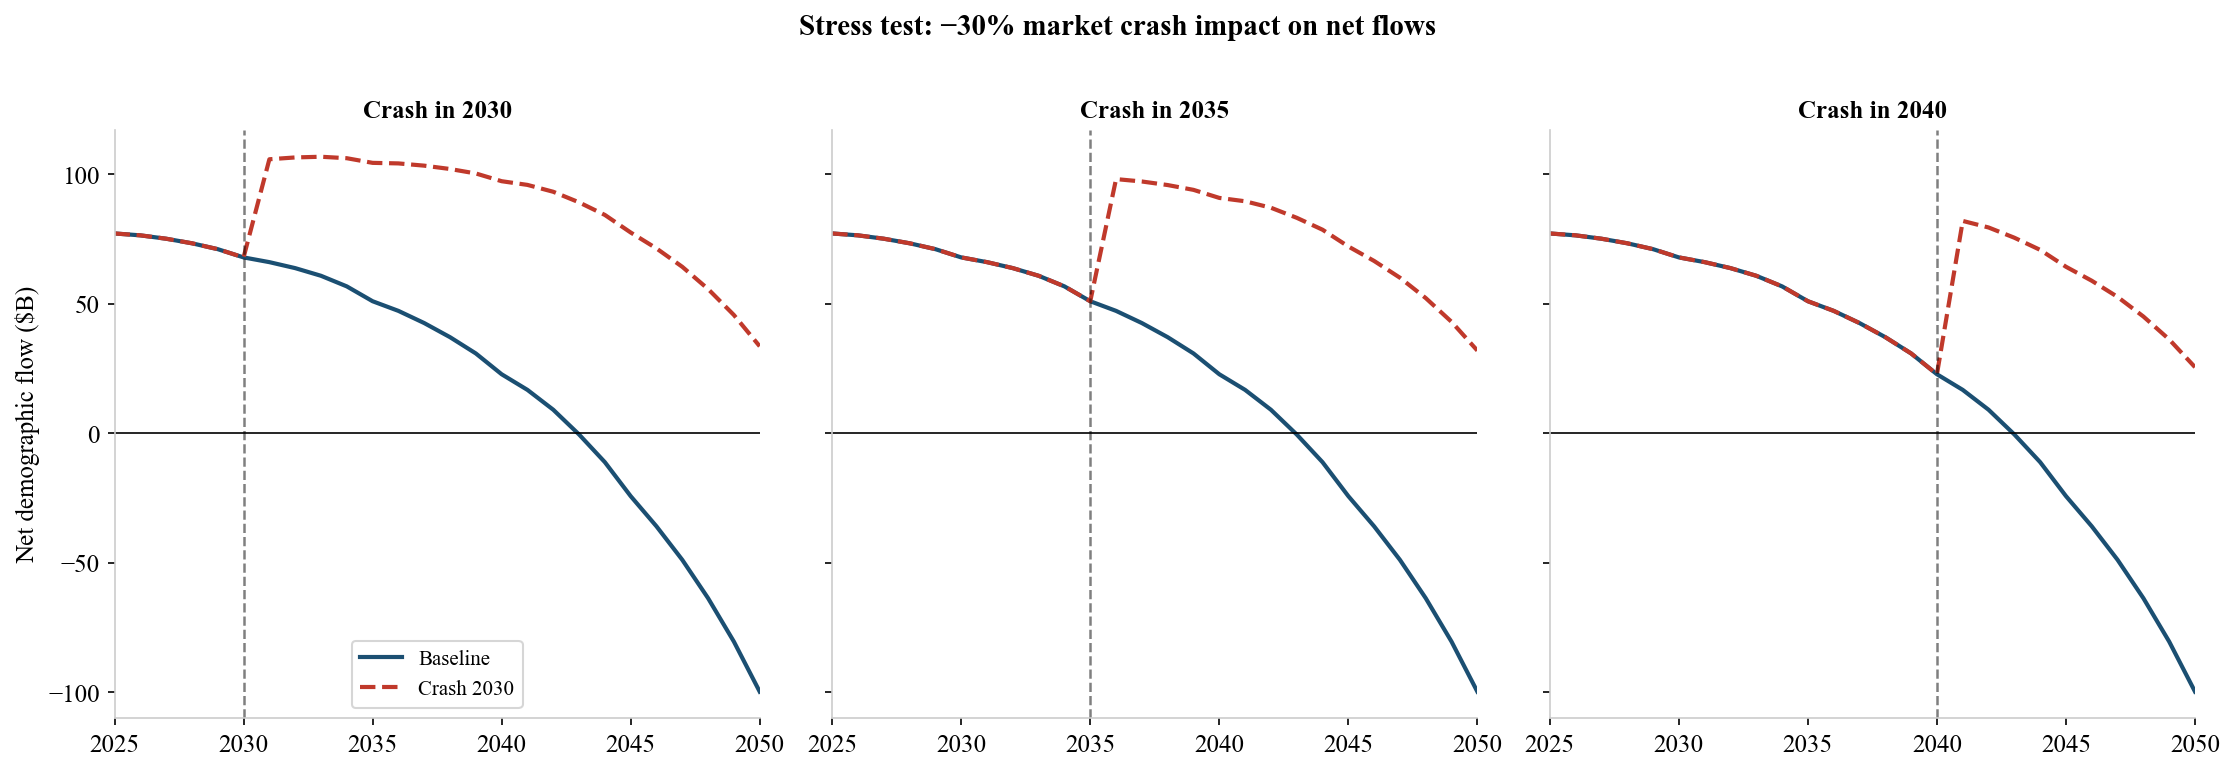

In [96]:
# ── Crash Stress Test ────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

stress_years = [2030, 2035, 2040]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, facecolor='white')

C_CRASH = '#C0392B'

for idx, s_year in enumerate(stress_years):
    ax = axes[idx]
    ax.set_facecolor('white')
    ax.plot(YEARS, stress_baseline_net, '-', color=PAL['navy'], linewidth=2, label='Baseline')
    ax.plot(YEARS, stress_net[idx], '--', color=C_CRASH, linewidth=2, label=f'Crash {s_year}')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axvline(x=s_year, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
    ax.set_title(f'Crash in {s_year}', fontsize=12, fontweight='bold', color='black')
    ax.set_xlim(2025, 2050)
    ax.set_xlabel('')
    ax.tick_params(colors='black', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.grid(False)
    if idx == 0:
        ax.set_ylabel('Net demographic flow ($B)', fontsize=12, color='black')
        ax.legend(fontsize=10)

plt.suptitle('Stress test: −30% market crash impact on net flows',
             fontsize=14, fontweight='bold', color='black', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT}\\mc_stress_test.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## M=2 Multiplier Stress Test

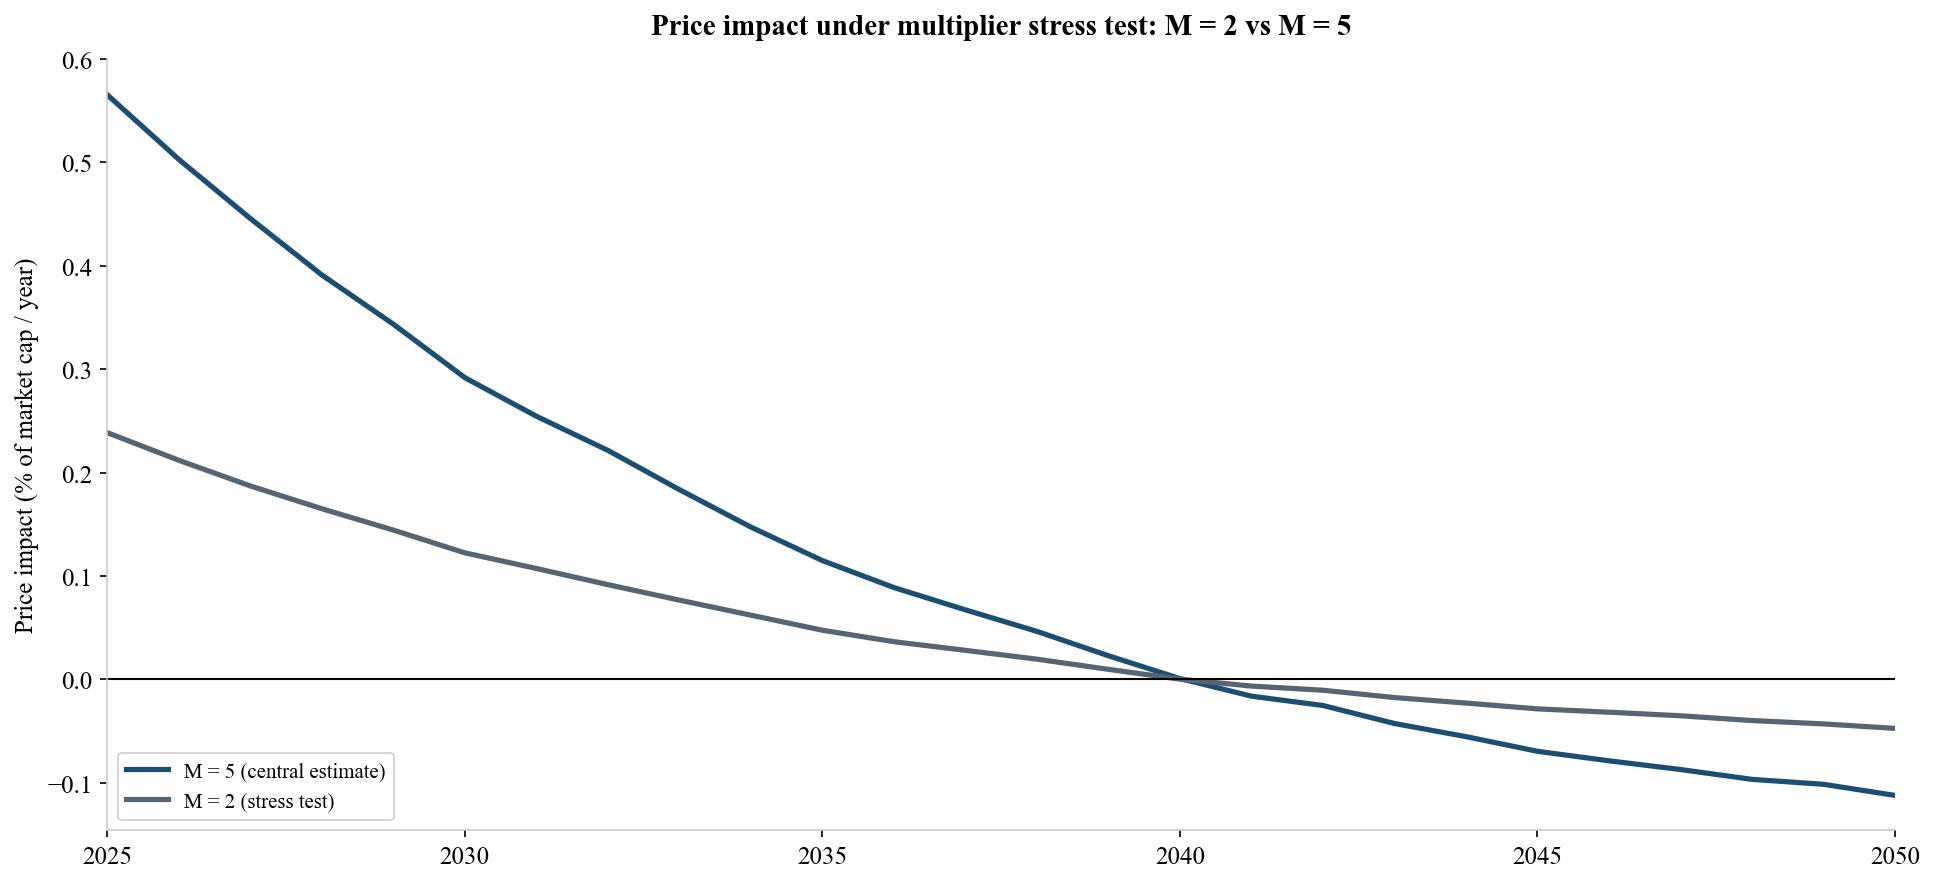

M=2 stress test vs M=5 central — median price impact (% of mkt cap):
  Year    M=5 median    M=2 median     Ratio
------------------------------------------
  2025        0.565%        0.239%     2.37x
  2030        0.292%        0.122%     2.38x
  2035        0.115%        0.048%     2.41x
  2040        0.001%        0.000%     0.00x
  2045       -0.069%       -0.028%     2.44x
  2050       -0.112%       -0.047%     2.37x

Key: The multiplier affects magnitude, not direction.
Both M=5 and M=2 turn negative as demographic outflows grow.
M=5 amplifies the drag ~2.5x more than M=2 (Haddad adjustment widens gap).


In [97]:
# ── M=2 Stress Test: multiplier symmetry defence ────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

pi_m2_pcts = np.percentile(mc_pi_m2, [5, 25, 50, 75, 95], axis=0)
pi_m5_pcts = np.percentile(mc_price_impact, [5, 25, 50, 75, 95], axis=0)

fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')
ax.set_facecolor('white')

ax.plot(YEARS, pi_m5_pcts[2], '-', color=PAL['navy'], linewidth=2.5,
        label='M = 5 (central estimate)')
ax.plot(YEARS, pi_m2_pcts[2], '-', color='#566573', linewidth=2.5,
        label='M = 2 (stress test)')

ax.axhline(y=0, color='black', linewidth=1)

ax.set_title('Price impact under multiplier stress test: M = 2 vs M = 5',
             fontsize=14, fontweight='bold', color='black', pad=12)
ax.set_ylabel('Price impact (% of market cap / year)', fontsize=12, color='black')
ax.set_xlim(2025, 2050)
ax.set_ylim(None, 0.6)
ax.legend(loc='lower left', fontsize=10)
ax.tick_params(colors='black', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(False)

plt.tight_layout()
plt.savefig(f'{OUT}\\mc_m2_stress_test.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

# Hard numbers
print('M=2 stress test vs M=5 central — median price impact (% of mkt cap):')
print(f"{'Year':>6}  {'M=5 median':>12}  {'M=2 median':>12}  {'Ratio':>8}")
print(f"{'-'*42}")
for yr_idx, yr in enumerate(YEARS):
    if yr % 5 == 0 or yr == 2025:
        m5 = pi_m5_pcts[2][yr_idx]
        m2 = pi_m2_pcts[2][yr_idx]
        ratio = m5 / m2 if abs(m2) > 0.001 else 0
        print(f'{yr:>6}  {m5:>11.3f}%  {m2:>11.3f}%  {ratio:>7.2f}x')

print(f'\nKey: The multiplier affects magnitude, not direction.')
print(f'Both M=5 and M=2 turn negative as demographic outflows grow.')
print(f'M=5 amplifies the drag ~2.5x more than M=2 (Haddad adjustment widens gap).')

## TDF 30% Equity Sensitivity

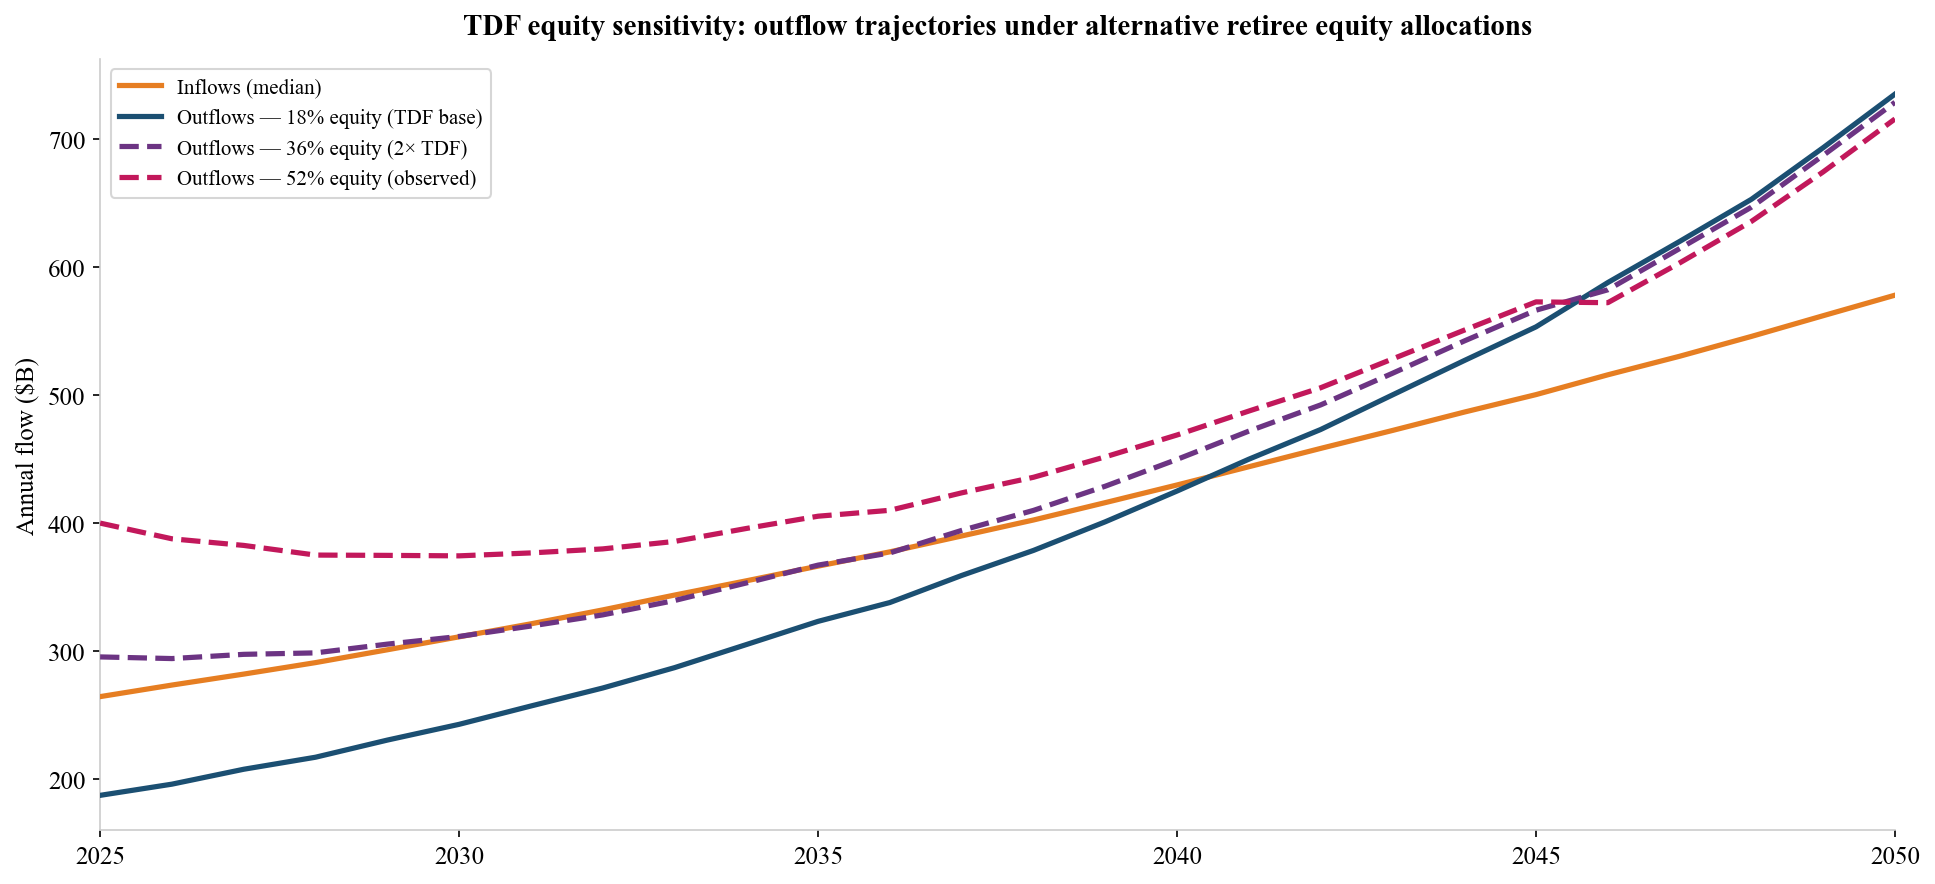


TDF Sensitivity — Median outflows ($B):
  Year    18% (base)   36% (2×TDF)     52% (obs)     Inflows
--------------------------------------------------------
  2025  $     187.6B  $     295.6B  $     400.1B  $   264.6B
  2030  $     243.0B  $     311.6B  $     374.6B  $   311.3B
  2035  $     323.4B  $     367.3B  $     405.5B  $   366.5B
  2040  $     425.1B  $     449.9B  $     468.9B  $   429.9B
  2045  $     553.3B  $     566.3B  $     572.8B  $   500.4B
  2050  $     735.1B  $     728.6B  $     715.6B  $   578.1B
  Base (18%): prob=91.1%, median first negative=2031
  36% (2×TDF): prob=99.7%, median first negative=2025
  52% (observed): prob=100.0%, median first negative=2025


In [101]:
# ── TDF Equity Sensitivity ───────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

out_base_med    = np.median(data['tdf_base_outflows'], axis=0)
out_sens_med_36 = np.median(data['tdf_sens_outflows_36'], axis=0)
out_sens_med_52 = np.median(data['tdf_sens_outflows_52'], axis=0)
in_base_med     = np.median(data['tdf_base_inflows'], axis=0)

fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')
ax.set_facecolor('white')

ax.plot(YEARS, in_base_med, '-', color='#E67E22', linewidth=2.5,
        label='Inflows (median)', zorder=5)
ax.plot(YEARS, out_base_med, '-', color='#1B4F72', linewidth=2.5,
        label='Outflows — 18% equity (TDF base)', zorder=5)
ax.plot(YEARS, out_sens_med_36, '--', color='#6C3483', linewidth=2.5,
        label='Outflows — 36% equity (2× TDF)', zorder=5)
ax.plot(YEARS, out_sens_med_52, '--', color='#C2185B', linewidth=2.5,
        label='Outflows — 52% equity (observed)', zorder=5)

ax.set_title('TDF equity sensitivity: outflow trajectories under alternative retiree equity allocations',
             fontsize=14, fontweight='bold', color='black', pad=12)
ax.set_ylabel('Annual flow ($B)', fontsize=12, color='black')
ax.set_xlim(2025, 2050)
ax.legend(loc='upper left', fontsize=10)
ax.tick_params(colors='black', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(False)

plt.tight_layout()
plt.savefig(f'{OUT}\\mc_tdf_sensitivity.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

# Key numbers
print(f'\nTDF Sensitivity — Median outflows ($B):')
print(f"{'Year':>6}  {'18% (base)':>12}  {'36% (2×TDF)':>12}  {'52% (obs)':>12}  {'Inflows':>10}")
print(f"{'-'*56}")
for yr in [2025, 2030, 2035, 2040, 2045, 2050]:
    idx = yr - 2025
    print(f'{yr:>6}  ${out_base_med[idx]:>10.1f}B  ${out_sens_med_36[idx]:>10.1f}B  ${out_sens_med_52[idx]:>10.1f}B  ${in_base_med[idx]:>8.1f}B')

# Crossover stats
for label, key in [('Base (18%)', 'tdf_cross_base'),
                    ('36% (2×TDF)', 'tdf_cross_sens_36'),
                    ('52% (observed)', 'tdf_cross_sens_52')]:
    arr = data[key]
    valid = arr[arr < 2099]
    prob = (arr < 2099).sum() / len(arr) * 100
    med = int(np.median(valid)) if len(valid) > 0 else 'N/A'
    print(f'  {label}: prob={prob:.1f}%, median first negative={med}')

## MC Convergence Diagnostic (Appendix)

N=   500: Crossover prob = 91.6%
N=  1000: Crossover prob = 92.3%
N=  2500: Crossover prob = 92.0%
N=  5000: Crossover prob = 91.7%
N=  7500: Crossover prob = 91.7%
N= 10000: Crossover prob = 91.6%
N= 15000: Crossover prob = 91.4%
N= 20000: Crossover prob = 91.3%
N= 25000: Crossover prob = 91.2%


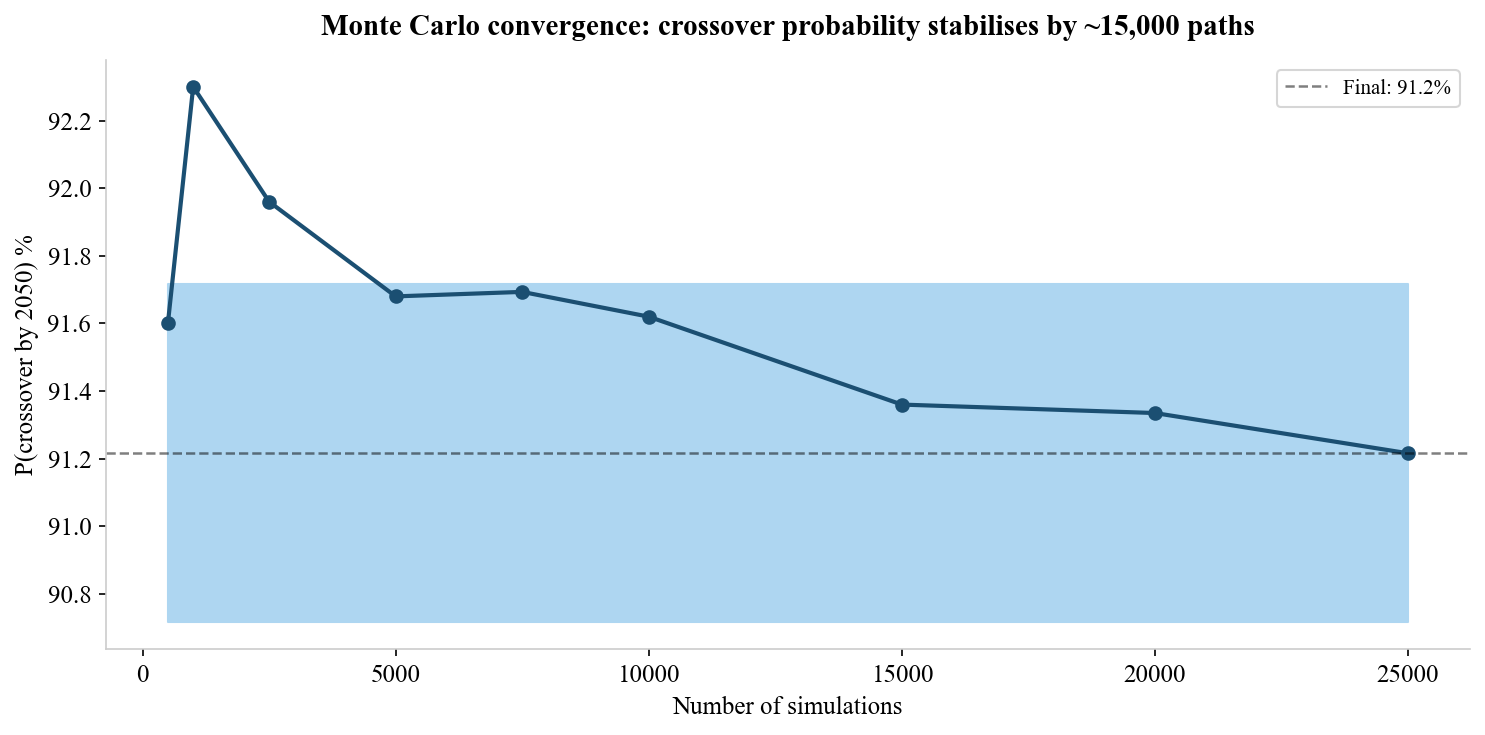

  N=15000: Δ from final = 0.14 pp (PASS)
  N=20000: Δ from final = 0.12 pp (PASS)
  N=25000: Δ from final = 0.00 pp (PASS)


In [103]:
# ── ITEM A5: MC Convergence Diagnostic ──────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

sample_sizes = [500, 1000, 2500, 5000, 7500, 10000, 15000, 20000, 25000]
convergence = []

for n in sample_sizes:
    subset = mc_crossover_demo[:n]
    prob = (subset < 2099).sum() / n * 100
    convergence.append((n, prob))
    print(f'N={n:>6}: Crossover prob = {prob:.1f}%')

fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
ax.set_facecolor('white')

ns, probs = zip(*convergence)
ax.plot(ns, probs, 'o-', color=PAL['navy'], linewidth=2, markersize=6)
ax.axhline(y=probs[-1], color='black', linestyle='--', linewidth=1.2, alpha=0.5,
           label=f'Final: {probs[-1]:.1f}%')
ax.fill_between(ns, [probs[-1] - 0.5]*len(ns), [probs[-1] + 0.5]*len(ns),
                color='#AED6F1')

ax.set_title('Monte Carlo convergence: crossover probability stabilises by ~15,000 paths',
             fontsize=14, fontweight='bold', color='black', pad=12)
ax.set_xlabel('Number of simulations', fontsize=12, color='black')
ax.set_ylabel('P(crossover by 2050) %', fontsize=12, color='black')
ax.legend(fontsize=10)
ax.tick_params(colors='black', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(False)

plt.tight_layout()
plt.savefig(f'{OUT}\\mc_convergence.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

for n, p in convergence:
    if n >= 15000:
        delta = abs(p - probs[-1])
        print(f'  N={n}: Δ from final = {delta:.2f} pp ({"PASS" if delta < 0.5 else "CHECK"})')

## Immigration Scenario Disaggregation (Appendix)

In [ ]:
# ── ITEM A9: Immigration Scenario Disaggregation ────────────────────
# Paper reference: Appendix, referenced in Section 5.2.

print(f"{'='*60}")
print('CROSSOVER BY DEMOGRAPHIC SCENARIO')
print(f"{'='*60}")

scenario_probs = {}
for scenario in ['mid', 'hi', 'low']:
    mask = (demo_choices == scenario)
    subset = mc_crossover_demo[mask]
    n_cross = (subset < 2050).sum()
    prob = n_cross / mask.sum() * 100
    median_yr = int(np.median(subset[subset < 2050])) if n_cross > 0 else 'N/A'
    scenario_probs[scenario] = prob
    print(f'  {scenario:>4}: N={mask.sum():>6,}, Crossover prob={prob:.1f}%, '
          f'Median year={median_yr}')

# Validation: weighted average should equal overall
weights = {'mid': 0.4, 'hi': 0.3, 'low': 0.3}
weighted_prob = sum(weights[s] * scenario_probs[s] for s in ['mid', 'hi', 'low'])
overall_prob = (mc_crossover_demo < 2050).mean() * 100
print(f'\n  Weighted average: {weighted_prob:.1f}%')
print(f'  Overall:          {overall_prob:.1f}%')
print(f'  Match: {"PASS" if abs(weighted_prob - overall_prob) < 1.0 else "CHECK"}')
print(f'\nExpected pattern: high immigration → lower prob, low → higher prob')
print(f'  hi ({scenario_probs["hi"]:.1f}%) < mid ({scenario_probs["mid"]:.1f}%) < '
      f'low ({scenario_probs["low"]:.1f}%): '
      f'{"PASS" if scenario_probs["hi"] < scenario_probs["mid"] < scenario_probs["low"] else "CHECK"}')


CROSSOVER BY DEMOGRAPHIC SCENARIO
   mid: N= 9,913, Crossover prob=90.6%, Median year=2031
    hi: N= 7,580, Crossover prob=89.1%, Median year=2031
   low: N= 7,507, Crossover prob=91.5%, Median year=2031

  Weighted average: 90.4%
  Overall:          90.4%
  Match: PASS

Expected pattern: high immigration → lower prob, low → higher prob
  hi (89.1%) < mid (90.6%) < low (91.5%): PASS


## Out-of-Sample Validation

Loaded regression_merged_data.csv: 69 quarterly obs


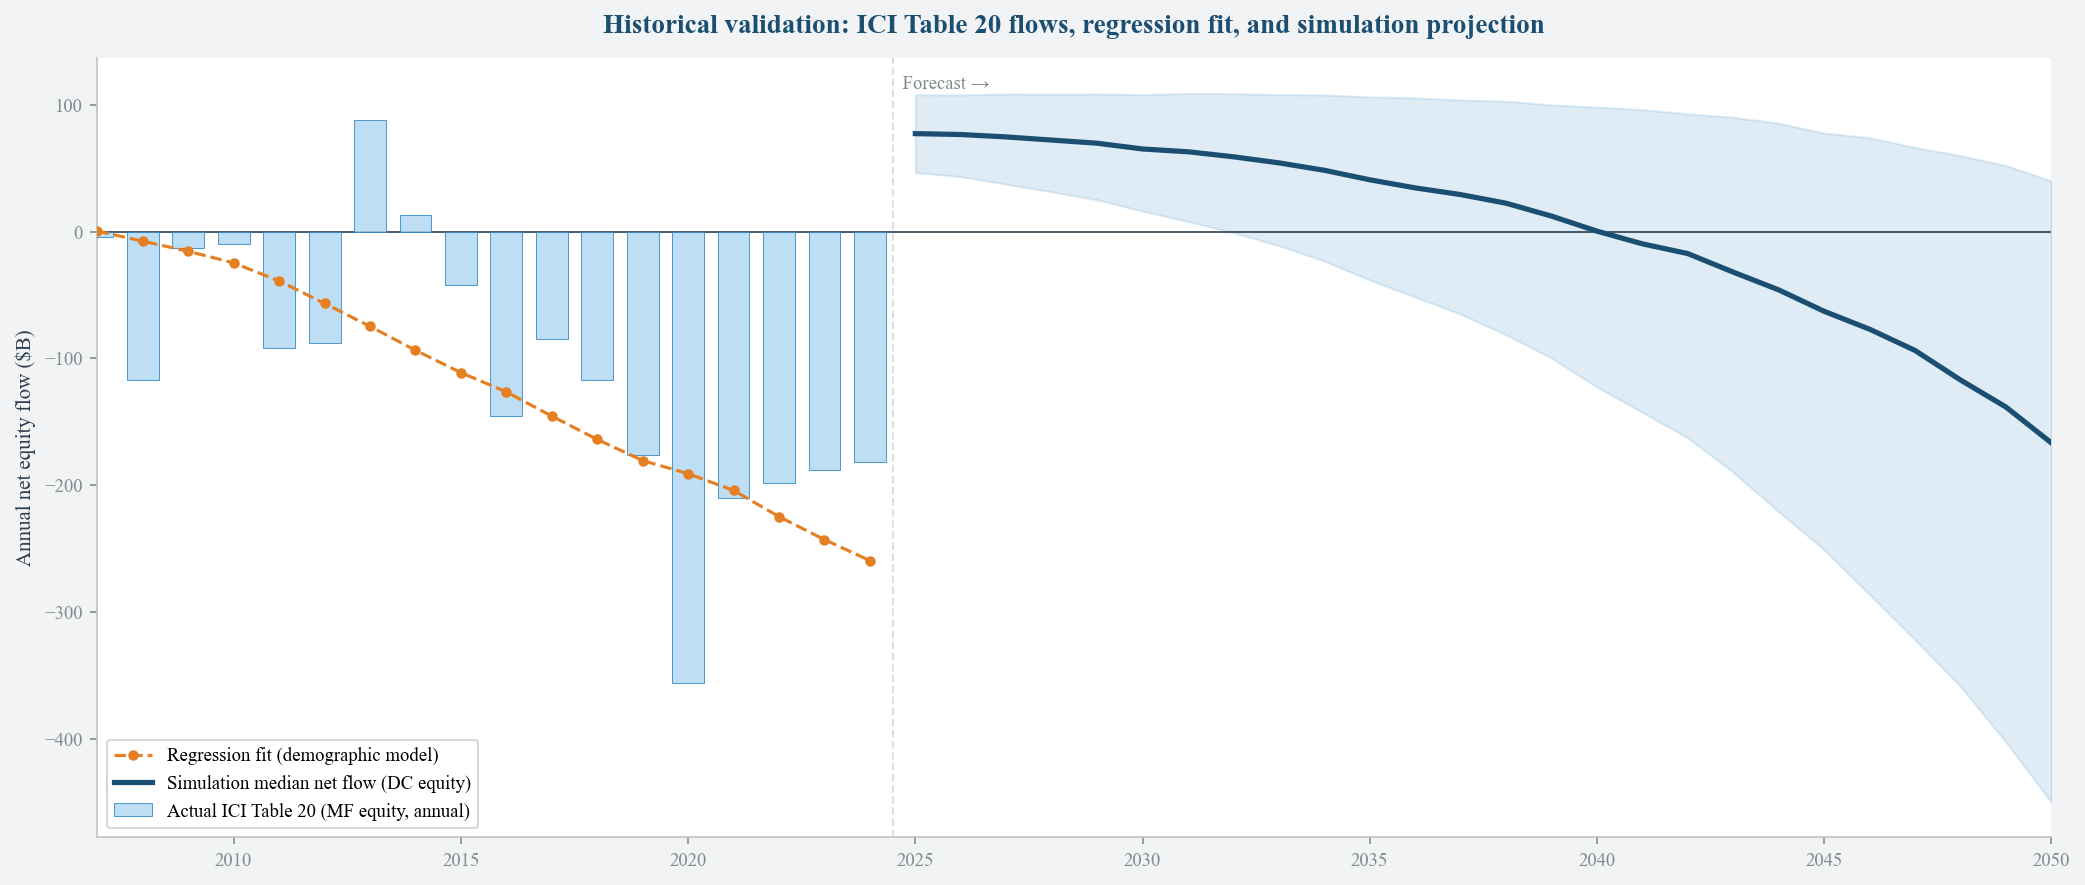


Out-of-sample comparison (annual $B):
  Year    Actual ICI    Reg. Fit   Model Net
------------------------------------------
  2018  $      -117B  $    -164B         —
  2019  $      -176B  $    -180B         —
  2020  $      -356B  $    -191B         —
  2021  $      -210B  $    -204B         —
  2022  $      -198B  $    -225B         —
  2023  $      -188B  $    -243B         —
  2024  $      -182B  $    -259B         —
  2025          —          —  $    77.2B

Last observed year (2024):
  Actual: $-182B  |  Regression fit: $-259B
  Model 2025 net: +$77.2B (DC equity only, not MF total)

Note: ICI Table 20 captures MF equity flows (declining due to MF→ETF
migration). The model projects DC plan equity flows specifically.
The regression validates the demographic mechanism; the simulation
applies it through the structural pipeline.


In [ ]:
# ── Out-of-Sample Validation: Model vs Historical ICI Table 20 Flows ──
# Loads the merged quarterly data from NB03 (ICI equity MF flows +
# Census 65+ population + S&P 500 returns, 2007-2024).
# Computes annualised actual flows and overlays the regression fit
# with the model's 2025-2050 net flow projection.
#
# IMPORTANT LIMITATIONS:
# - ICI Table 20 = mutual fund equity flows only (excludes ETFs)
# - Model projects DC plan equity flows (different scope)
# - Regression provides the bridge: historical demographic relationship
#   → validates the structural mechanism, not the exact dollar amount

try:
    merged_q = pd.read_csv(f'{PROC}\\regression_merged_data.csv', index_col=0, parse_dates=True)
    print(f'Loaded regression_merged_data.csv: {len(merged_q)} quarterly obs')
except FileNotFoundError:
    merged_q = None
    print('regression_merged_data.csv not found — skipping OOS validation')

if merged_q is not None:
    # Annualise quarterly data
    # Resample to annual (pandas >=2.2 uses 'YE', older uses 'A')
    try:
        annual_oos = merged_q.resample('YE').agg({'equity_flow': 'sum', 'pop_65plus': 'last'}).dropna()
    except ValueError:
        annual_oos = merged_q.resample('A').agg({'equity_flow': 'sum', 'pop_65plus': 'last'}).dropna()
    annual_oos = annual_oos[annual_oos.index.year <= 2024]

    # Regression prediction (annualised)
    try:
        _reg = pd.read_csv(f'{PROC}\\regression_output.csv')
        beta_const = _reg['beta_const'].values[0]
        beta_pop = _reg['beta_pop_65plus'].values[0]
    except (FileNotFoundError, KeyError):
        beta_const, beta_pop = 109.042, -2.839  # fallback
    annual_oos['regression_fit'] = (beta_const + beta_pop * annual_oos['pop_65plus']) * 4

    # Model's projected net flow (median from MC)
    model_median_net = np.median(mc_net_demo, axis=0)

    fig, ax = plt.subplots(figsize=(14, 6))

    # Historical actual
    ax.bar(annual_oos.index.year, annual_oos['equity_flow'], width=0.7,
           color=PAL['sky'], edgecolor=PAL['blue'], linewidth=0.5,
           alpha=0.8, label='Actual ICI Table 20 (MF equity, annual)', zorder=3)

    # Regression fit
    ax.plot(annual_oos.index.year, annual_oos['regression_fit'], 'o--',
            color=PAL['amber'], linewidth=1.5, markersize=4,
            label='Regression fit (demographic model)', zorder=4)

    # Model projection (2025-2050)
    ax.plot(YEARS, model_median_net, '-', color=PAL['navy'], linewidth=2.5,
            label='Simulation median net flow (DC equity)', zorder=5)
    ax.fill_between(YEARS,
                    np.percentile(mc_net_demo, 25, axis=0),
                    np.percentile(mc_net_demo, 75, axis=0),
                    alpha=0.15, color=PAL['blue'], zorder=2)

    ax.axhline(0, color=PAL['charcoal'], linewidth=0.8)
    ax.axvline(2024.5, color=PAL['silver'], linewidth=1, linestyle='--', alpha=0.5)
    ax.text(2024.5, ax.get_ylim()[1]*0.9, '  Forecast \u2192', fontsize=9,
            color=PAL['slate'], va='top')

    ax.set_title('Historical validation: ICI Table 20 flows, regression fit, and simulation projection',
                 fontsize=13, fontweight='bold', color=PAL['navy'], pad=12)
    ax.set_ylabel('Annual net equity flow ($B)')
    ax.set_xlim(2007, 2050)
    ax.legend(loc='lower left', fontsize=9)
    clean_spines(ax)

    plt.tight_layout()
    plt.savefig(f'{OUT}\\oos_validation.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Hard numbers
    print(f'\nOut-of-sample comparison (annual $B):')
    print(f"{'Year':>6}  {'Actual ICI':>12}  {'Reg. Fit':>10}  {'Model Net':>10}")
    print(f"{'-'*42}")
    for yr in range(2018, 2025):
        row = annual_oos[annual_oos.index.year == yr]
        if len(row) > 0:
            actual = row['equity_flow'].values[0]
            regfit = row['regression_fit'].values[0]
            print(f'{yr:>6}  ${actual:>10.0f}B  ${regfit:>8.0f}B         —')
    # Model 2025 baseline
    print(f'{2025:>6}          —          —  ${model_median_net[0]:>8.1f}B')

    # Key insight
    last_actual = annual_oos['equity_flow'].iloc[-1]
    last_regfit = annual_oos['regression_fit'].iloc[-1]
    print(f'\nLast observed year ({annual_oos.index[-1].year}):')
    print(f'  Actual: ${last_actual:.0f}B  |  Regression fit: ${last_regfit:.0f}B')
    print(f'  Model 2025 net: +${model_median_net[0]:.1f}B (DC equity only, not MF total)')
    print(f'\nNote: ICI Table 20 captures MF equity flows (declining due to MF\u2192ETF')
    print(f'migration). The model projects DC plan equity flows specifically.')
    print(f'The regression validates the demographic mechanism; the simulation')
    print(f'applies it through the structural pipeline.')


In [ ]:
# ── Extract crash stress test numbers for paper ──────────────────────
print("CRASH STRESS TEST — numbers for paper")
print("=" * 65)
for j, s_year in enumerate([2030, 2035, 2040]):
    ci = s_year - 2025        # crash year index
    pi = ci + 1               # post-crash year index
    print(f"\nCrash in {s_year}:")
    print(f"  Baseline net at {s_year}:   ${stress_baseline_net[ci]:+.1f}B")
    print(f"  Baseline net at {s_year+1}: ${stress_baseline_net[pi]:+.1f}B")
    print(f"  Stress net at {s_year+1}:   ${stress_net[j, pi]:+.1f}B")
    print(f"  Swing at {s_year+1}:        ${stress_net[j, pi] - stress_baseline_net[pi]:+.1f}B")
print(f"\nBaseline zero crossing:")
for t in range(len(YEARS)-1):
    if stress_baseline_net[t] >= 0 and stress_baseline_net[t+1] < 0:
        print(f"  Baseline turns negative between {YEARS[t]} and {YEARS[t+1]}")
        break

CRASH STRESS TEST — numbers for paper

Crash in 2030:
  Baseline net at 2030:   $+67.9B
  Baseline net at 2031: $+66.1B
  Stress net at 2031:   $+105.8B
  Swing at 2031:        $+39.7B

Crash in 2035:
  Baseline net at 2035:   $+51.0B
  Baseline net at 2036: $+47.2B
  Stress net at 2036:   $+98.1B
  Swing at 2036:        $+50.9B

Crash in 2040:
  Baseline net at 2040:   $+22.8B
  Baseline net at 2041: $+16.7B
  Stress net at 2041:   $+82.0B
  Swing at 2041:        $+65.3B

Baseline zero crossing:
  Baseline turns negative between 2042 and 2043


In [ ]:
data = np.load(r'..\data\processed\mc_results.npz')
median_net = np.median(data['mc_net_demo'], axis=0)
for t, yr in enumerate(range(2025, 2051)):
    if median_net[t] < 0:
        print(f'MC median crosses between {yr-1} and {yr}')
        print(f'  {yr-1}: {median_net[t-1]:+.1f}B')
        print(f'  {yr}: {median_net[t]:+.1f}B')
        break

MC median crosses between 2040 and 2041
  2040: +0.4B
  2041: -9.6B


In [ ]:
data = np.load(r'..\data\processed\mc_results.npz')
net_total = data['mc_net_total']
# For paths that cross, how many are negative at 2050?
crossed = net_total[data['mc_crossover_total'] < 2099]
print(f'Paths that crossed: {len(crossed)}')
print(f'Of those, negative at 2050: {(crossed[:, 25] < 0).sum()}')
print(f'Of those, positive at 2050: {(crossed[:, 25] >= 0).sum()}')

Paths that crossed: 1115
Of those, negative at 2050: 79
Of those, positive at 2050: 1036


In [ ]:
data = np.load(r'..\data\processed\mc_results.npz')
base_out = data['tdf_base_outflows']
sens_out = data['tdf_sens_outflows']
base_in = data['tdf_base_inflows']
median_diff = np.median(sens_out - base_out, axis=0)
for t, yr in enumerate(range(2025, 2051)):
    if yr >= 2033 and yr <= 2040:
        pct_diff = median_diff[t] / np.median(base_out[:, t]) * 100
        print(f'{yr}: median outflow difference = {median_diff[t]:+.1f}B ({pct_diff:+.1f}%)')

2033: median outflow difference = +113.5B (+39.6%)
2034: median outflow difference = +121.7B (+39.8%)
2035: median outflow difference = +129.6B (+40.0%)
2036: median outflow difference = -3.0B (-0.9%)
2037: median outflow difference = -3.2B (-0.9%)
2038: median outflow difference = -3.5B (-0.9%)
2039: median outflow difference = -3.7B (-0.9%)
2040: median outflow difference = -4.0B (-0.9%)


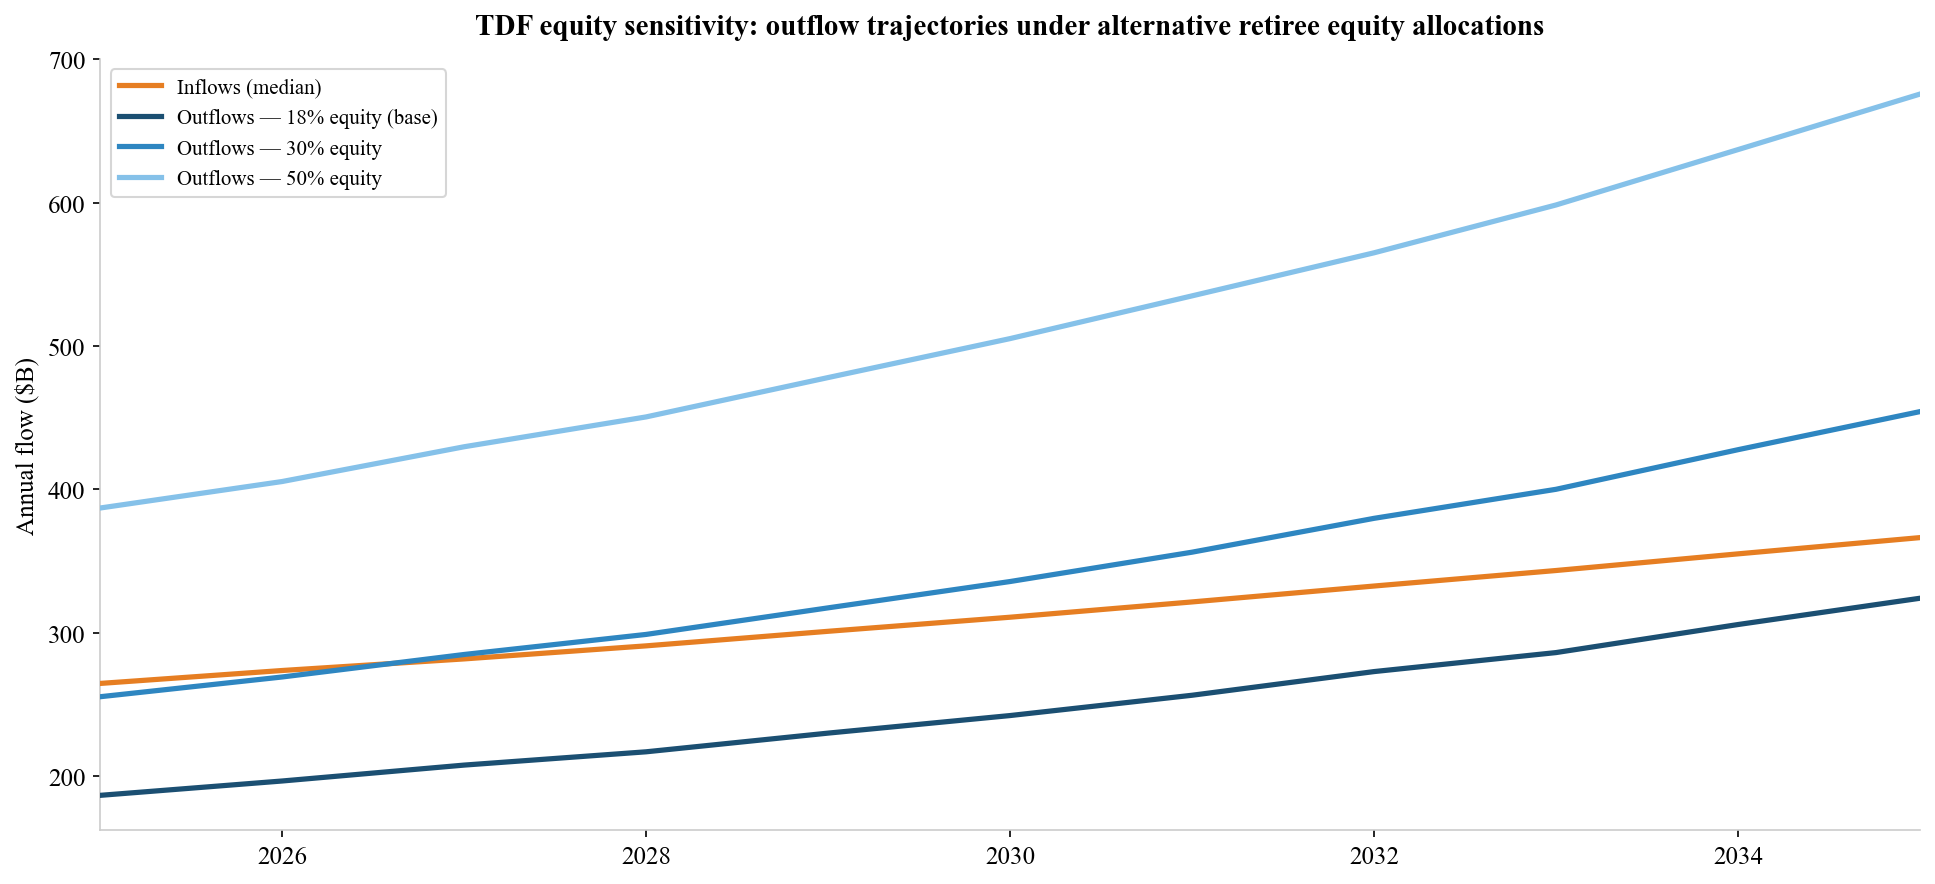


Key numbers:
  2025: 18%=$186.7B  30%=$255.5B  50%=$387.1B  Inflows=$264.8B
  2030: 18%=$242.4B  30%=$335.8B  50%=$505.2B  Inflows=$310.9B
  2035: 18%=$324.2B  30%=$454.3B  50%=$675.7B  Inflows=$366.4B


In [ ]:
# ── TDF Equity Sensitivity Chart ─────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

PROC = r'..\data\processed'
OUT  = r'..\outputs'
YEARS = np.arange(2025, 2051)

mc_data = np.load(f'{PROC}\\mc_results.npz')
tdf_50  = np.load(f'{PROC}\\tdf_50_sensitivity.npz')

out_base_med_18 = np.median(mc_data['tdf_base_outflows'], axis=0)
out_sens_med_30 = np.median(mc_data['tdf_sens_outflows'], axis=0)
out_sens_med_50 = np.median(tdf_50['out_sens_50'], axis=0)
in_base_med     = np.median(mc_data['tdf_base_inflows'], axis=0)

fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')
ax.set_facecolor('white')

# Truncate at 2035 — override ends here
mask = YEARS <= 2035

ax.plot(YEARS[mask], in_base_med[mask], '-', color='#E67E22', linewidth=2.5,
        label='Inflows (median)', zorder=5)
ax.plot(YEARS[mask], out_base_med_18[mask], '-', color='#1B4F72', linewidth=2.5,
        label='Outflows — 18% equity (base)', zorder=5)
ax.plot(YEARS[mask], out_sens_med_30[mask], '-', color='#2E86C1', linewidth=2.5,
        label='Outflows — 30% equity', zorder=5)
ax.plot(YEARS[mask], out_sens_med_50[mask], '-', color='#85C1E9', linewidth=2.5,
        label='Outflows — 50% equity', zorder=5)

ax.set_title('TDF equity sensitivity: outflow trajectories under alternative retiree equity allocations',
             fontsize=14, fontweight='bold', color='black', pad=12)
ax.set_ylabel('Annual flow ($B)', fontsize=12, color='black')
ax.set_xlim(2025, 2035)
ax.legend(loc='upper left', fontsize=10)
ax.tick_params(colors='black', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(False)

plt.tight_layout()
plt.savefig(f'{OUT}\\mc_tdf_sensitivity.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print(f'\nKey numbers:')
for yr in [2025, 2030, 2035]:
    idx = yr - 2025
    print(f'  {yr}: 18%=${out_base_med_18[idx]:.1f}B  30%=${out_sens_med_30[idx]:.1f}B  50%=${out_sens_med_50[idx]:.1f}B  Inflows=${in_base_med[idx]:.1f}B')